# OOBMeanPath — Unified Ablation and Mechanism Study

This notebook is the **single ablation-study codebase** intended to accompany the separate real-data benchmark notebook.

It contains only the analyses needed to support this study:

1. **Same-fitted-forest scoring ablation on every ARFF/MAT dataset in `DATA_DIR`**
   - 20 fixed matched seeds
   - \(T=500\)
   - `AllTree` versus `OOBMeanPath` using exactly the same fitted trees
   - exact finite-forest correction \(C_i\)
   - one defined cross-dataset mechanism test

2. **Effective-OOB-tree / tree-count sensitivity study on every discovered dataset**
   - \(T\in\{100,250,500,1000\}\)
   - 20 matched seeds
   - nested prefixes of one 1000-tree forest per dataset/seed
   - OOB path MCSE scaling
   - direct empirical check of the theoretically predicted \(T^{-1/2}\) law
   - stability of the finite-forest correction
   - \(T=500\)-versus-\(T=1000\) convergence

3. **summary robustness diagnostics**
   - seed-level SDs
   - leave-one-dataset-out stability
   - basic covariate checks
   - controlled-effect win/loss summaries
   - reproducibility checks and final CSV/figure outputs

This notebook **does not search for gates, thresholds, or new variants**. The real-data analysis code remains separate and unchanged.

---

## Primary mechanism quantity

For observation \(i\), define the exact finite-forest correction

\[
C_i=\widehat\mu_i^{ALL}-\widehat\mu_i^{OOB}.
\]

With the standard Isolation Forest score

\[
s_i=2^{-\widehat\mu_i/c(\psi)},
\]

we have exactly

\[
\log_2\!\left(\frac{s_i^{OOB}}{s_i^{ALL}}\right)
=\frac{C_i}{c(\psi)}.
\]

Define

\[
G_C=E(C_i\mid y_i=1)-E(C_i\mid y_i=0).
\]

The **single primary cross-dataset test** is

\[
H_0:\rho_S(G_C,\Delta ROC)\le0
\qquad\text{vs}\qquad
H_1:\rho_S(G_C,\Delta ROC)>0,
\]

where

\[
\Delta ROC=ROC_{OOBMeanPath}-ROC_{AllTree}.
\]

The independent units are the discovered datasets after averaging the 20 matched seeds within each dataset. AP, tree-count sensitivity, covariate checks, and leave-one-dataset-out analyses are supporting analyses.

In [1]:
# Imports and fixed configuration
from pathlib import Path
import json
import math
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat, arff
from scipy import sparse
from scipy.stats import spearmanr, rankdata, wilcoxon
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

# Put this notebook in the directory containing the dataset files,
# or change DATA_DIR before the first execution. Every .arff and .mat
# file directly inside DATA_DIR is included, in case-insensitive order.
DATA_DIR = Path(".").resolve()
OUTPUT_DIR = DATA_DIR / "OOBMeanPath_Unified_Ablation_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SUPPORTED_SUFFIXES = {".arff", ".mat"}
DATASET_PATHS = sorted(
    [
        p for p in DATA_DIR.iterdir()
        if p.is_file() and p.suffix.lower() in SUPPORTED_SUFFIXES
    ],
    key=lambda p: p.name.casefold(),
)
if not DATASET_PATHS:
    raise FileNotFoundError(
        f"No .arff or .mat files were found directly in {DATA_DIR}."
    )

DATASETS = [p.name for p in DATASET_PATHS]
if len({name.casefold() for name in DATASETS}) != len(DATASETS):
    raise ValueError("Dataset filenames must be unique ignoring case.")
DATASET_PATH_BY_NAME = {p.name: p for p in DATASET_PATHS}

T = 500
CONTAMINATION = 0.10
MAX_FEATURES = 1.0
BOOTSTRAP = False
N_JOBS = -1

# Fixed before execution. Do not change after seeing results.
SEEDS = list(range(20270813, 20270833))   # exactly 20 seeds

# Primary permutation test settings
N_PERMUTATIONS = 200_000
PERMUTATION_SEED = 20260830

assert len(SEEDS) == 20

# Tree-count / MCSE scaling is evaluated on every discovered dataset.
# This evaluates the verification across the full discovered dataset collection for the
# theoretically predicted T^{-1/2} Monte Carlo scaling law.
T_SENSITIVITY_DATASETS = list(DATASETS)

T_CHECKPOINTS = [100, 250, 500, 1000]
T_MAX = max(T_CHECKPOINTS)

LOADER_VERSION = "folder_arff_mat_v2_ecoli_fallback"

CONFIG = {
    "experiment": "OOBMeanPath Unified Ablation and Mechanism Study",
    "T": T,
    "n_seeds": len(SEEDS),
    "seeds": SEEDS,
    "contamination": CONTAMINATION,
    "max_features": MAX_FEATURES,
    "bootstrap": BOOTSTRAP,
    "psi_rule": "min(256, max(2, floor(0.8*n)), n-1)",
    "primary_endpoint": "Spearman(G_C, mean_OOB_minus_All_ROC)",
    "primary_alternative": "greater",
    "n_permutations": N_PERMUTATIONS,
    "permutation_seed": PERMUTATION_SEED,
    "loader_version": LOADER_VERSION,
    "data_dir": str(DATA_DIR),
    "datasets": DATASETS,
    "t_sensitivity_datasets": T_SENSITIVITY_DATASETS,
    "T_checkpoints": T_CHECKPOINTS,
}

with open(OUTPUT_DIR / "experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=2)

print(f"Discovered {len(DATASETS)} dataset files in {DATA_DIR}")
print(json.dumps(CONFIG, indent=2))

Discovered 30 dataset files in C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Ablation Study 3
{
  "experiment": "OOBMeanPath Unified Ablation and Mechanism Study",
  "T": 500,
  "n_seeds": 20,
  "seeds": [
    20270813,
    20270814,
    20270815,
    20270816,
    20270817,
    20270818,
    20270819,
    20270820,
    20270821,
    20270822,
    20270823,
    20270824,
    20270825,
    20270826,
    20270827,
    20270828,
    20270829,
    20270830,
    20270831,
    20270832
  ],
  "contamination": 0.1,
  "max_features": 1.0,
  "bootstrap": false,
  "psi_rule": "min(256, max(2, floor(0.8*n)), n-1)",
  "primary_endpoint": "Spearman(G_C, mean_OOB_minus_All_ROC)",
  "primary_alternative": "greater",
  "n_permutations": 200000,
  "permutation_seed": 20260830,
  "loader_version": "folder_arff_mat_v2_ecoli_fallback",
  "data_dir": "C:\\Users\\jzhou\\Desktop\\Academics\\Research\\Outlier Detection\\OOBMeanPath\\Refined and su

## Dataset loading and preprocessing

The preprocessing follows this study pipeline:

- decode byte strings;
- remove the target before modeling;
- treat non-finite numeric values as missing;
- encode categorical predictors with an explicit missing category;
- remove all-missing and constant predictors;
- median-impute remaining numeric missing values;
- standardize predictors.

Target resolution is audited for every discovered file:

- standard target names such as `outlier`, `class`, `label`, `target`, and `y` are detected case-insensitively;
- semantic anomaly/normal labels are resolved before any fallback;
- known source rules are retained for multiclass Arrhythmia and Shuttle and for named binary benchmarks;
- unresolved binary targets use the minority class, with the chosen rule recorded in `loader_audit.csv`;
- MAT files accept `X`/`y` and common aliases and automatically correct a transposed feature matrix when dimensions identify it unambiguously;
- a degenerate `ecoli.mat` is reconstructed from the canonical UCI Ecoli source, using `omL`, `imL`, and `imS` as anomalies.

In [2]:
TARGET_CANDIDATES = (
    "outlier", "class", "target", "label", "y", "outcome", "response"
)

ANOMALY_TOKENS = {
    "1", "yes", "true", "outlier", "anomaly", "anomalous", "abnormal",
    "positive", "malignant", "recurrence", "recur", "death", "dead",
    "failed", "failure", "attack", "bad", "b",
}
NORMAL_TOKENS = {
    "0", "no", "false", "inlier", "normal", "negative", "benign",
    "healthy", "nonrecurrence", "non-recurrence", "good", "g",
}

# Known multiclass source definitions. These are not inferred from prevalence.
NORMAL_VS_REST_RULES = {
    "arrhythmia.arff": {"1"},
    "shuttle.arff": {"1"},
}

# Known binary source definitions whose anomalous class has a semantic label.
POSITIVE_TOKEN_RULES = {
    "hepatitis.arff": {"1", "death", "dead", "die", "died"},
    "pima-indians-diabetes.arff": {
        "1", "tested_positive", "positive", "yes", "true"
    },
    "seismic-bumps.arff": {"1", "yes", "true", "positive"},
    "spambase.arff": {"1", "yes", "true", "spam"},
    "wdbc.arff": {"2"},
    "wpbc.arff": {"1", "r", "recurrence", "recur", "yes", "true"},
}


def _decode_scalar(v):
    if isinstance(v, (bytes, bytearray)):
        return v.decode("utf-8", errors="replace")
    return v


def _clean_token(v):
    v = _decode_scalar(v)
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if s.casefold() in {"?", "nan", "none", "null", ""}:
        return np.nan
    return s


def _canonical_token(v):
    """Normalize labels while preserving nonnumeric semantic values."""
    s = _clean_token(v)
    if pd.isna(s):
        return np.nan
    try:
        number = float(s)
        if np.isfinite(number):
            if number.is_integer():
                return str(int(number))
            return format(number, ".17g")
    except (TypeError, ValueError):
        pass
    return str(s).strip().casefold()


def _find_target_column(df, preferred=TARGET_CANDIDATES):
    lower_map = {str(c).strip().casefold(): c for c in df.columns}
    for name in preferred:
        if name.casefold() in lower_map:
            return lower_map[name.casefold()]

    # ARFF benchmark targets are commonly the last attribute. Use that fallback
    # only when it has a plausible class cardinality.
    fallback = df.columns[-1]
    cardinality = df[fallback].map(_canonical_token).nunique(dropna=True)
    max_classes = max(2, min(50, int(np.sqrt(max(len(df), 1))) + 1))
    if 2 <= cardinality <= max_classes:
        warnings.warn(
            f"No standard target name found; using last ARFF attribute "
            f"{fallback!r} with {cardinality} classes.",
            RuntimeWarning,
        )
        return fallback

    raise KeyError(
        f"Could not identify the target column. Available columns: "
        f"{list(df.columns)}; tried names: {preferred}."
    )


def _resolve_binary_labels(filename, raw, target_name):
    tokens = pd.Series(raw).map(_canonical_token)
    if tokens.isna().any():
        n_missing = int(tokens.isna().sum())
        raise ValueError(f"{filename}: target contains {n_missing} missing values.")

    counts = tokens.value_counts(dropna=False)
    unique = set(counts.index.astype(str))
    if len(unique) < 2:
        raise ValueError(f"{filename}: target has fewer than two classes: {unique}")

    key = filename.casefold()
    target_key = str(target_name).strip().casefold()

    if key in NORMAL_VS_REST_RULES:
        normal = NORMAL_VS_REST_RULES[key]
        y = (~tokens.isin(normal)).astype(int)
        return y.to_numpy(dtype=int), f"source rule: {sorted(normal)} normal; rest anomalous"

    if key in POSITIVE_TOKEN_RULES:
        positive = POSITIVE_TOKEN_RULES[key]
        y = tokens.isin(positive).astype(int)
        if y.nunique() == 2:
            return y.to_numpy(dtype=int), f"source rule: {sorted(positive)} anomalous"

    anomaly_hits = unique.intersection(ANOMALY_TOKENS)
    normal_hits = unique.intersection(NORMAL_TOKENS)

    # A column explicitly called outlier takes semantic yes/anomaly labels first.
    if target_key == "outlier" and anomaly_hits:
        y = tokens.isin(anomaly_hits).astype(int)
        if y.nunique() == 2:
            return y.to_numpy(dtype=int), f"semantic outlier labels: {sorted(anomaly_hits)}"

    if len(unique) == 2:
        if len(anomaly_hits) == 1:
            y = tokens.isin(anomaly_hits).astype(int)
            return y.to_numpy(dtype=int), f"semantic anomaly label: {sorted(anomaly_hits)}"

        if len(normal_hits) == 1:
            y = (~tokens.isin(normal_hits)).astype(int)
            return y.to_numpy(dtype=int), f"semantic normal label: {sorted(normal_hits)}; complement anomalous"

        numeric = pd.to_numeric(tokens, errors="coerce")
        if numeric.notna().all() and set(numeric.unique()) == {0.0, 1.0}:
            y = (numeric == 1.0).astype(int)
            return y.to_numpy(dtype=int), "binary numeric label: 1 anomalous"

        # For an otherwise unresolved binary benchmark, use the minority class.
        # The chosen raw value is recorded in the audit output.
        positive = str(counts.idxmin())
        y = (tokens == positive).astype(int)
        return y.to_numpy(dtype=int), f"binary minority label: {positive} anomalous"

    if normal_hits:
        y = (~tokens.isin(normal_hits)).astype(int)
        if y.nunique() == 2:
            return y.to_numpy(dtype=int), f"normal labels {sorted(normal_hits)}; rest anomalous"

    if anomaly_hits:
        y = tokens.isin(anomaly_hits).astype(int)
        if y.nunique() == 2:
            return y.to_numpy(dtype=int), f"anomaly labels: {sorted(anomaly_hits)}"

    positive = str(counts.idxmin())
    y = (tokens == positive).astype(int)
    return y.to_numpy(dtype=int), f"multiclass minority label: {positive} anomalous"


def _prepare_predictors(df):
    df = df.copy()
    parts = []

    for col in df.columns:
        s = df[col]

        if pd.api.types.is_numeric_dtype(s):
            z = pd.to_numeric(s, errors="coerce").astype(float)
            z = z.replace([np.inf, -np.inf], np.nan)
            if z.notna().sum() == 0:
                continue
            z = z.fillna(z.median())
            parts.append(pd.DataFrame({str(col): z}))
        else:
            z = s.map(_clean_token)
            z = z.where(pd.notna(z), "__MISSING__").astype(str)
            dummies = pd.get_dummies(
                z,
                prefix=str(col),
                dummy_na=False,
                dtype=float,
            )
            parts.append(dummies)

    if not parts:
        raise ValueError("No usable predictors after preprocessing.")

    Xdf = pd.concat(parts, axis=1)
    Xdf = Xdf.apply(pd.to_numeric, errors="coerce")
    Xdf = Xdf.replace([np.inf, -np.inf], np.nan)
    Xdf = Xdf.loc[:, Xdf.notna().any(axis=0)]

    for c in Xdf.columns:
        if Xdf[c].isna().any():
            med = Xdf[c].median()
            if not np.isfinite(med):
                med = 0.0
            Xdf[c] = Xdf[c].fillna(med)

    Xdf = Xdf.loc[:, Xdf.nunique(dropna=False) > 1]

    if Xdf.shape[1] == 0:
        raise ValueError("No nonconstant predictors after preprocessing.")

    return Xdf.to_numpy(dtype=float), list(map(str, Xdf.columns))


def load_arff_dataset(path):
    data, _ = arff.loadarff(path)
    df = pd.DataFrame(data)
    if df.empty:
        raise ValueError(f"{path.name}: ARFF file contains no rows.")
    target = _find_target_column(df)
    y, rule = _resolve_binary_labels(path.name, df[target], target)
    X, feature_names = _prepare_predictors(df.drop(columns=[target]))
    return X, y, feature_names, rule


def _find_mat_key(obj, candidates):
    key_map = {
        str(k).strip().casefold(): k
        for k in obj
        if not str(k).startswith("__")
    }
    for candidate in candidates:
        if candidate.casefold() in key_map:
            return key_map[candidate.casefold()]
    return None


ECOLI_UCI_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data"
)
ECOLI_ANOMALY_CLASSES = {"oml", "iml", "ims"}


def _load_ecoli_from_uci(mat_path):
    """Reconstruct a degenerate ecoli.mat from the canonical UCI data."""
    import io
    import urllib.request

    local_candidates = [
        mat_path.with_name("ecoli.data"),
        mat_path.with_name("ecoli_uci.data"),
        OUTPUT_DIR / "ecoli_uci_source.data",
    ]
    source_text = None
    source_description = None

    for candidate in local_candidates:
        if candidate.exists():
            source_text = candidate.read_text(encoding="utf-8")
            source_description = str(candidate)
            break

    if source_text is None:
        try:
            request = urllib.request.Request(
                ECOLI_UCI_URL,
                headers={"User-Agent": "Mozilla/5.0"},
            )
            with urllib.request.urlopen(request, timeout=30) as response:
                source_text = response.read().decode("utf-8")
            source_description = ECOLI_UCI_URL
            cache_path = OUTPUT_DIR / "ecoli_uci_source.data"
            cache_path.write_text(source_text, encoding="utf-8")
        except Exception as exc:
            raise RuntimeError(
                "ecoli.mat has a degenerate target and cannot be used directly. "
                "Automatic retrieval of the canonical UCI Ecoli data also failed. "
                "Download ecoli.data from the UCI Ecoli dataset and place it next "
                "to ecoli.mat, then rerun the loader-audit cell."
            ) from exc

    columns = [
        "sequence", "mcg", "gvh", "lip", "chg",
        "aac", "alm1", "alm2", "class",
    ]
    frame = pd.read_csv(
        io.StringIO(source_text),
        sep=r"\s+",
        header=None,
        names=columns,
        comment="#",
    )
    if frame.shape[1] != len(columns) or frame.empty:
        raise ValueError(
            f"Canonical Ecoli source has an unexpected shape: {frame.shape}."
        )

    class_tokens = frame["class"].astype(str).str.strip().str.casefold()
    y = class_tokens.isin(ECOLI_ANOMALY_CLASSES).astype(int).to_numpy()
    Xdf = frame[["mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2"]]
    X, feature_names = _prepare_predictors(Xdf)

    if len(X) != 336 or int(y.sum()) != 9:
        raise ValueError(
            "Canonical Ecoli reconstruction failed validation: expected "
            f"336 observations and 9 anomalies, got n={len(X)}, anomalies={int(y.sum())}."
        )

    rule = (
        "UCI Ecoli reconstruction; classes omL, imL, imS anomalous; "
        f"source={source_description}"
    )
    return X, y, feature_names, rule


def load_mat_dataset(path):
    obj = loadmat(path)
    available = [k for k in obj if not k.startswith("__")]

    x_key = _find_mat_key(obj, ("X", "data", "features", "inputs"))
    y_key = _find_mat_key(obj, ("y", "label", "labels", "target", "targets", "class"))

    if x_key is None or y_key is None:
        raise KeyError(
            f"{path.name}: could not identify feature/label variables. "
            f"Expected X plus y (or common aliases); found {available}."
        )

    X = obj[x_key]
    y_raw = obj[y_key]

    if sparse.issparse(X):
        X = X.toarray()
    if sparse.issparse(y_raw):
        y_raw = y_raw.toarray()

    X = np.asarray(X)
    y_raw = np.asarray(y_raw).reshape(-1)

    if X.ndim != 2:
        raise ValueError(f"{path.name}: {x_key} is not two-dimensional: {X.shape}")
    if X.shape[0] != len(y_raw) and X.shape[1] == len(y_raw):
        X = X.T
    if X.shape[0] != len(y_raw):
        raise ValueError(
            f"{path.name}: label length {len(y_raw)} does not match "
            f"feature shape {X.shape}."
        )

    try:
        X = np.asarray(X, dtype=float)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{path.name}: feature matrix is not numeric.") from exc

    if path.name.casefold() == "ecoli.mat":
        target_classes = pd.Series(y_raw).map(_canonical_token).nunique(dropna=True)
        if target_classes < 2 or not np.isfinite(X).any():
            warnings.warn(
                "ecoli.mat is degenerate; reconstructing it from the canonical "
                "UCI Ecoli source.",
                RuntimeWarning,
            )
            return _load_ecoli_from_uci(path)

    y, rule = _resolve_binary_labels(path.name, y_raw, y_key)
    Xdf = pd.DataFrame(X)
    X_clean, _ = _prepare_predictors(Xdf)
    feature_names = [f"x{j}" for j in range(X_clean.shape[1])]
    return X_clean, y, feature_names, f"MAT {y_key}; {rule}"


def load_dataset(path):
    suffix = path.suffix.lower()
    if suffix == ".arff":
        return load_arff_dataset(path)
    if suffix == ".mat":
        return load_mat_dataset(path)
    raise ValueError(f"Unsupported file type: {path}")


def validate_dataset(X, y, name):
    if X.ndim != 2:
        raise ValueError(f"{name}: X must be 2D.")
    if len(X) != len(y):
        raise ValueError(f"{name}: X/y length mismatch.")
    if len(y) < 3:
        raise ValueError(f"{name}: at least three observations are required.")
    if not np.isfinite(X).all():
        raise ValueError(f"{name}: X contains non-finite values after cleaning.")
    classes = np.unique(y)
    if not np.array_equal(classes, np.array([0, 1])):
        raise ValueError(f"{name}: expected binary y in {{0,1}}, got {classes}.")
    if y.sum() == 0 or y.sum() == len(y):
        raise ValueError(f"{name}: requires both classes.")


def psi_rule(n):
    return int(min(256, max(2, math.floor(0.8 * n)), n - 1))

In [3]:
# Audit every discovered dataset before any forests are fitted.
audit_rows = []
loader_errors = []

for name in DATASETS:
    path = DATASET_PATH_BY_NAME[name]
    try:
        X, y, feature_names, label_rule = load_dataset(path)
        validate_dataset(X, y, name)
    except Exception as exc:
        loader_errors.append({
            "dataset": name,
            "error_type": type(exc).__name__,
            "error": str(exc),
        })
        continue

    audit_rows.append({
        "dataset": name,
        "file_type": path.suffix.lower(),
        "n": len(y),
        "d_after_cleaning": X.shape[1],
        "n_anomalies": int(y.sum()),
        "prevalence": float(y.mean()),
        "psi": psi_rule(len(y)),
        "q_oob": 1.0 - psi_rule(len(y)) / len(y),
        "expected_oob_trees_T500": T * (1.0 - psi_rule(len(y)) / len(y)),
        "expected_inbag_trees_T500": T * (psi_rule(len(y)) / len(y)),
        "prob_zero_inbag_approx": (1.0 - psi_rule(len(y)) / len(y)) ** T,
        "expected_zero_inbag_observations_approx": len(y) * (
            (1.0 - psi_rule(len(y)) / len(y)) ** T
        ),
        "label_rule": label_rule,
    })

loader_audit = pd.DataFrame(audit_rows)
loader_audit.to_csv(OUTPUT_DIR / "loader_audit.csv", index=False)
display(loader_audit)

if loader_errors:
    loader_error_table = pd.DataFrame(loader_errors)
    loader_error_table.to_csv(OUTPUT_DIR / "loader_errors.csv", index=False)
    display(loader_error_table)
    details = "\n".join(
        f"  - {row['dataset']}: {row['error_type']}: {row['error']}"
        for row in loader_errors
    )
    raise RuntimeError(
        f"{len(loader_errors)} of {len(DATASETS)} dataset files failed the "
        f"loader audit:\n{details}\nSee loader_errors.csv for the complete audit."
    )

print(f"\nLoaded all {len(DATASETS)} discovered datasets successfully.")

,dataset,file_type,n,d_after_cleaning,n_anomalies,prevalence,psi,q_oob,expected_oob_trees_T500,expected_inbag_trees_T500,prob_zero_inbag_approx,expected_zero_inbag_observations_approx,label_rule
0,Annthyroid_withoutdupl_07.arff,.arff,7129,22,534,0.074905,256,0.964090,482.045168,17.954832,1.145156e-08,8.163816e-05,semantic outlier labels: ['yes']
1,arrhythmia.arff,.arff,452,326,207,0.457965,256,0.433628,216.814159,283.185841,3.620915e-182,1.636653e-179,source rule: ['1'] normal; rest anomalous
2,breastw.mat,.mat,683,9,239,0.349927,256,0.625183,312.591508,187.408492,1.008290e-102,6.886624e-100,MAT y; semantic anomaly label: ['1']
3,cardio.mat,.mat,1831,21,176,0.096122,256,0.860186,430.092845,69.907155,1.977456e-33,3.620723e-30,MAT y; semantic anomaly label: ['1']
4,Cardiotocography_22.arff,.arff,2126,22,471,0.221543,256,0.879586,439.793039,60.206961,1.377759e-28,2.929115e-25,semantic outlier labels: ['yes']
5,Cardiotocography_withoutdupl_norm_10_v10.arff,.arff,1831,22,183,0.099945,256,0.860186,430.092845,69.907155,1.977456e-33,3.620723e-30,semantic outlier labels: ['yes']
6,HeartDisease_withoutdupl_44.arff,.arff,270,14,120,0.444444,216,0.200000,100.000000,400.000000,0.000000e+00,0.000000e+00,semantic outlier labels: ['yes']
7,hepatitis.arff,.arff,155,42,32,0.206452,124,0.200000,100.000000,400.000000,0.000000e+00,0.000000e+00,"source rule: ['1', 'dead', 'death', 'die', 'di..."
8,InternetAds_withoutdupl_norm_19.arff,.arff,1966,1556,368,0.187182,256,0.869786,434.893184,65.106816,5.085088e-31,9.997282e-28,semantic outlier labels: ['yes']
9,KDDCup99_original.arff,.arff,60839,78,246,0.004043,256,0.995792,497.896086,2.103914,1.214379e-01,7.388158e+03,semantic outlier labels: ['yes']



Loaded all 30 discovered datasets successfully.


## Same-forest scoring implementation

For each fitted tree and observation, the path length is

\[
H_{it}
=
\text{leaf depth}_{it}
+
c(n_{\text{leaf},it})
-1,
\]

where \(c(\cdot)\) is the standard Isolation Forest expected unsuccessful-search path length.

From the exact same 500 fitted trees we accumulate the all-tree and in-bag contributions; OOB contributions follow by subtraction.

### Why the primary quantity is \(G_C\), not unweighted \(G_D\), across all discovered datasets

For large datasets with \(\psi=256\), an observation may appear in zero in-bag
trees even when \(T=500\). Its in-bag mean path is then undefined. This is
expected sampling behavior, not an implementation failure.

The exact finite-forest correction

\[
C_i=\widehat\mu_i^{ALL}-\widehat\mu_i^{OOB}
\]

does not require an in-bag mean. Whenever the latter exists,

\[
C_i=\frac{M_i^{IB}}{T}
\left(
\widehat\mu_i^{IB}-\widehat\mu_i^{OOB}
\right).
\]

Thus \(C_i\) is the universally defined finite-forest form of the same mechanism,
and it directly determines the OOB-vs-AllTree score shift. The full-benchmark
primary test therefore uses

\[
G_C=E(C_i\mid y=1)-E(C_i\mid y=0).
\]

The notebook still reports a complete-case unweighted \(G_D\) only as a
secondary diagnostic.

### scikit-learn dtype compatibility note

`DecisionTree.apply(..., check_input=False)` expects `np.float32` input in recent
scikit-learn versions. The same-forest scorer therefore converts each tree's
feature slice to contiguous `float32` before calling `tree.apply`. This does not
change the fitted forest or experiment design; it matches scikit-learn's internal
prediction dtype handling.

In [4]:
EULER_GAMMA = np.euler_gamma

def average_path_length(n):
    # Vectorized sklearn-compatible c(n).
    arr = np.asarray(n)
    out = np.zeros(arr.shape, dtype=float)

    mask2 = arr == 2
    out[mask2] = 1.0

    mask = arr > 2
    nm = arr[mask].astype(float)
    out[mask] = 2.0 * (np.log(nm - 1.0) + EULER_GAMMA) - 2.0 * (nm - 1.0) / nm

    if np.ndim(n) == 0:
        return float(out)
    return out

def _tree_path_lengths(tree, Xz, feat_idx):
    # Recent sklearn tree internals require float32 with check_input=False.
    Xt = np.asarray(Xz[:, feat_idx], dtype=np.float32, order="C")
    leaves = tree.apply(Xt, check_input=False)
    node_depth = tree.tree_.compute_node_depths()[leaves].astype(float)
    leaf_n = tree.tree_.n_node_samples[leaves]
    return node_depth + average_path_length(leaf_n) - 1.0


def _summarize_accumulators(
    y, psi, T_used,
    all_sum, all_sq_sum,
    ib_sum, ib_sq_sum, ib_count,
):
    n = len(y)
    cpsi = average_path_length(psi)

    oob_sum = all_sum - ib_sum
    oob_sq_sum = all_sq_sum - ib_sq_sum
    oob_count = T_used - ib_count

    if np.any(oob_count == 0):
        bad = np.flatnonzero(oob_count == 0)
        raise RuntimeError(
            f"{len(bad)} observations have zero OOB trees at T={T_used}."
        )

    mean_all = all_sum / T_used
    mean_oob = oob_sum / oob_count
    correction_i = mean_all - mean_oob

    valid_ib = ib_count > 0
    mean_ib = np.full(n, np.nan, dtype=float)
    delta_i = np.full(n, np.nan, dtype=float)
    mean_ib[valid_ib] = ib_sum[valid_ib] / ib_count[valid_ib]
    delta_i[valid_ib] = mean_ib[valid_ib] - mean_oob[valid_ib]

    if valid_ib.any():
        rhs = (ib_count[valid_ib].astype(float) / T_used) * delta_i[valid_ib]
        identity_err = float(np.max(np.abs(correction_i[valid_ib] - rhs)))
        if identity_err > 1e-10:
            raise AssertionError(
                f"Finite-forest correction identity failed; max error={identity_err:.3e}"
            )
    else:
        identity_err = np.nan

    all_score = np.power(2.0, -mean_all / cpsi)
    oob_score = np.power(2.0, -mean_oob / cpsi)

    anomaly_mask = y == 1
    normal_mask = ~anomaly_mask

    G_C = float(
        correction_i[anomaly_mask].mean()
        - correction_i[normal_mask].mean()
    )
    G_log2_score = float(G_C / cpsi)

    valid_anom = anomaly_mask & valid_ib
    valid_norm = normal_mask & valid_ib
    if valid_anom.any() and valid_norm.any():
        G_D_complete = float(
            delta_i[valid_anom].mean() - delta_i[valid_norm].mean()
        )
    else:
        G_D_complete = np.nan

    if valid_ib.all():
        G_D_full = float(
            delta_i[anomaly_mask].mean() - delta_i[normal_mask].mean()
        )
    else:
        G_D_full = np.nan

    # Sample variance across eligible OOB-tree path lengths, then SE of the mean.
    m = oob_count.astype(float)
    valid_var = oob_count >= 2
    oob_sample_var = np.full(n, np.nan, dtype=float)
    numer = oob_sq_sum[valid_var] - (oob_sum[valid_var] ** 2) / m[valid_var]
    numer = np.maximum(numer, 0.0)
    oob_sample_var[valid_var] = numer / (m[valid_var] - 1.0)
    oob_mcse = np.full(n, np.nan, dtype=float)
    oob_mcse[valid_var] = np.sqrt(oob_sample_var[valid_var] / m[valid_var])

    return {
        "all_score": all_score,
        "oob_score": oob_score,
        "ib_count": ib_count.copy(),
        "oob_count": oob_count.copy(),
        "G_C": G_C,
        "G_log2_score": G_log2_score,
        "G_D_complete_cases": G_D_complete,
        "G_D_full": G_D_full,
        "fraction_with_inbag": float(valid_ib.mean()),
        "n_zero_inbag": int((~valid_ib).sum()),
        "finite_identity_max_error": identity_err,
        "median_oob_mcse": float(np.nanmedian(oob_mcse)),
        "mean_oob_mcse": float(np.nanmean(oob_mcse)),
    }


def score_same_forest(Xz, y, seed, T=T):
    """Fit one forest and compute AllTree/OOB scores from the same fitted trees."""
    n = Xz.shape[0]
    psi = psi_rule(n)
    p_inbag = psi / n
    q = 1.0 - p_inbag

    model = IsolationForest(
        n_estimators=T,
        max_samples=psi,
        contamination=CONTAMINATION,
        max_features=MAX_FEATURES,
        bootstrap=BOOTSTRAP,
        random_state=int(seed),
        n_jobs=N_JOBS,
    )

    t0 = time.perf_counter()
    model.fit(Xz)
    fit_seconds = time.perf_counter() - t0

    all_sum = np.zeros(n, dtype=np.float64)
    all_sq_sum = np.zeros(n, dtype=np.float64)
    ib_sum = np.zeros(n, dtype=np.float64)
    ib_sq_sum = np.zeros(n, dtype=np.float64)
    ib_count = np.zeros(n, dtype=np.int32)

    t1 = time.perf_counter()
    for tree, inbag_idx, feat_idx in zip(
        model.estimators_, model.estimators_samples_, model.estimators_features_
    ):
        H = _tree_path_lengths(tree, Xz, feat_idx)
        all_sum += H
        all_sq_sum += H * H
        ib_sum[inbag_idx] += H[inbag_idx]
        ib_sq_sum[inbag_idx] += H[inbag_idx] * H[inbag_idx]
        ib_count[inbag_idx] += 1
    score_seconds = time.perf_counter() - t1

    s = _summarize_accumulators(
        y, psi, T,
        all_sum, all_sq_sum,
        ib_sum, ib_sq_sum, ib_count,
    )

    sklearn_all_score = -model.score_samples(Xz)
    max_abs_alltree_check = float(
        np.max(np.abs(s["all_score"] - sklearn_all_score))
    )
    if max_abs_alltree_check > 1e-10:
        raise AssertionError(
            "AllTree score does not reproduce sklearn score_samples; "
            f"max difference={max_abs_alltree_check:.3e}"
        )

    roc_all = roc_auc_score(y, s["all_score"])
    roc_oob = roc_auc_score(y, s["oob_score"])
    ap_all = average_precision_score(y, s["all_score"])
    ap_oob = average_precision_score(y, s["oob_score"])

    return {
        "seed": int(seed),
        "T": int(T),
        "n": int(n),
        "d": int(Xz.shape[1]),
        "n_anomalies": int(y.sum()),
        "prevalence": float(y.mean()),
        "psi": int(psi),
        "p_inbag": float(p_inbag),
        "q_oob": float(q),
        "expected_oob_trees": float(T * q),
        "expected_inbag_trees": float(T * p_inbag),
        "mean_oob_count": float(s["oob_count"].mean()),
        "min_oob_count": int(s["oob_count"].min()),
        "mean_inbag_count": float(s["ib_count"].mean()),
        "min_inbag_count": int(s["ib_count"].min()),
        "n_zero_inbag": int(s["n_zero_inbag"]),
        "fraction_zero_inbag": float(s["n_zero_inbag"] / n),
        "fraction_with_inbag": float(s["fraction_with_inbag"]),
        "G_C": float(s["G_C"]),
        "G_log2_score": float(s["G_log2_score"]),
        "G_D_complete_cases": s["G_D_complete_cases"],
        "G_D_full": s["G_D_full"],
        "median_oob_mcse": float(s["median_oob_mcse"]),
        "mean_oob_mcse": float(s["mean_oob_mcse"]),
        "finite_identity_max_error": float(s["finite_identity_max_error"]),
        "AllTree_ROC": float(roc_all),
        "OOBMeanPath_ROC": float(roc_oob),
        "OOB_minus_All_ROC": float(roc_oob - roc_all),
        "AllTree_AP": float(ap_all),
        "OOBMeanPath_AP": float(ap_oob),
        "OOB_minus_All_AP": float(ap_oob - ap_all),
        "fit_seconds": float(fit_seconds),
        "score_seconds": float(score_seconds),
        "max_abs_AllTree_vs_sklearn": max_abs_alltree_check,
    }


def fit_nested_checkpoints(Xz, y, seed, checkpoints=T_CHECKPOINTS):
    """Fit one T_max forest and summarize nested prefixes at all checkpoints."""
    checkpoints = sorted(map(int, checkpoints))
    T_max = max(checkpoints)
    checkpoint_set = set(checkpoints)

    n = Xz.shape[0]
    psi = psi_rule(n)
    p_inbag = psi / n
    q = 1.0 - p_inbag

    model = IsolationForest(
        n_estimators=T_max,
        max_samples=psi,
        contamination=CONTAMINATION,
        max_features=MAX_FEATURES,
        bootstrap=BOOTSTRAP,
        random_state=int(seed),
        n_jobs=N_JOBS,
    )

    t0 = time.perf_counter()
    model.fit(Xz)
    fit_seconds = time.perf_counter() - t0

    all_sum = np.zeros(n, dtype=np.float64)
    all_sq_sum = np.zeros(n, dtype=np.float64)
    ib_sum = np.zeros(n, dtype=np.float64)
    ib_sq_sum = np.zeros(n, dtype=np.float64)
    ib_count = np.zeros(n, dtype=np.int32)

    rows = []
    for t, (tree, inbag_idx, feat_idx) in enumerate(
        zip(model.estimators_, model.estimators_samples_, model.estimators_features_),
        start=1,
    ):
        H = _tree_path_lengths(tree, Xz, feat_idx)
        all_sum += H
        all_sq_sum += H * H
        ib_sum[inbag_idx] += H[inbag_idx]
        ib_sq_sum[inbag_idx] += H[inbag_idx] * H[inbag_idx]
        ib_count[inbag_idx] += 1

        if t not in checkpoint_set:
            continue

        s = _summarize_accumulators(
            y, psi, t,
            all_sum, all_sq_sum,
            ib_sum, ib_sq_sum, ib_count,
        )
        roc_all = roc_auc_score(y, s["all_score"])
        roc_oob = roc_auc_score(y, s["oob_score"])
        ap_all = average_precision_score(y, s["all_score"])
        ap_oob = average_precision_score(y, s["oob_score"])

        rows.append({
            "seed": int(seed),
            "T": int(t),
            "n": int(n),
            "d": int(Xz.shape[1]),
            "n_anomalies": int(y.sum()),
            "prevalence": float(y.mean()),
            "psi": int(psi),
            "p_inbag": float(p_inbag),
            "q_oob": float(q),
            "expected_oob_trees": float(t * q),
            "expected_inbag_trees": float(t * p_inbag),
            "G_C": float(s["G_C"]),
            "G_log2_score": float(s["G_log2_score"]),
            "G_D_full": s["G_D_full"],
            "G_D_complete_cases": s["G_D_complete_cases"],
            "median_oob_mcse": float(s["median_oob_mcse"]),
            "mean_oob_mcse": float(s["mean_oob_mcse"]),
            "n_zero_inbag": int(s["n_zero_inbag"]),
            "fraction_with_inbag": float(s["fraction_with_inbag"]),
            "finite_identity_max_error": float(s["finite_identity_max_error"]),
            "AllTree_ROC": float(roc_all),
            "OOBMeanPath_ROC": float(roc_oob),
            "OOB_minus_All_ROC": float(roc_oob - roc_all),
            "AllTree_AP": float(ap_all),
            "OOBMeanPath_AP": float(ap_oob),
            "OOB_minus_All_AP": float(ap_oob - ap_all),
            "fit_seconds_Tmax": float(fit_seconds),
        })

    return rows

## Quick implementation smoke test

This is not part of this study inference. It checks that the same-forest `AllTree` computation reproduces sklearn's own training-sample score.

In [5]:
rng = np.random.default_rng(12345)
X_test = rng.normal(size=(180, 7))
y_test = np.zeros(180, dtype=int)
y_test[:18] = 1
X_test[:18] += 2.0
X_test = StandardScaler().fit_transform(X_test)

smoke = score_same_forest(X_test, y_test, seed=12345, T=100)
print("Smoke-test max |AllTree - sklearn|:",
      f"{smoke['max_abs_AllTree_vs_sklearn']:.3e}")
print("Smoke-test passed.")

Smoke-test max |AllTree - sklearn|: 1.110e-16
Smoke-test passed.


## Execute the folder-wide matched-seed experiment

The run is resumable. After each completed dataset × seed combination, the raw CSV is updated.

The design fits `len(DATASETS) × len(SEEDS)` forests, each with 500 trees.

In [6]:
RAW_CSV = OUTPUT_DIR / "seed_level_results.csv"

if RAW_CSV.exists():
    raw_existing = pd.read_csv(RAW_CSV)
    required_resume = {"dataset", "seed", "T", "loader_version"}
    if required_resume.issubset(raw_existing.columns):
        raw_existing = raw_existing.loc[
            raw_existing["dataset"].isin(DATASETS)
            & raw_existing["seed"].isin(SEEDS)
            & (raw_existing["T"] == T)
            & (raw_existing["loader_version"] == LOADER_VERSION)
        ].copy()
        raw_existing = raw_existing.drop_duplicates(
            ["dataset", "seed"], keep="last"
        )
    else:
        warnings.warn(
            "Existing seed-level output predates the folder-wide loader; "
            "starting a clean run.", RuntimeWarning
        )
        raw_existing = pd.DataFrame()
else:
    raw_existing = pd.DataFrame()

def completed_keys(df):
    if df.empty:
        return set()
    return set(zip(df["dataset"].astype(str), df["seed"].astype(int)))

done = completed_keys(raw_existing)
rows = raw_existing.to_dict("records") if not raw_existing.empty else []

total = len(DATASETS) * len(SEEDS)
counter = len(done)

for di, name in enumerate(DATASETS, 1):
    path = DATASET_PATH_BY_NAME[name]

    print("\n" + "=" * 88)
    print(f"[{di:02d}/{len(DATASETS)}] {name}")

    X, y, feature_names, label_rule = load_dataset(path)
    validate_dataset(X, y, name)
    Xz = StandardScaler().fit_transform(X)

    for si, seed in enumerate(SEEDS, 1):
        key = (name, int(seed))
        if key in done:
            print(f"  seed {si:02d}/20 = {seed}: already complete")
            continue

        t0 = time.perf_counter()
        res = score_same_forest(Xz, y, seed=seed, T=T)
        elapsed = time.perf_counter() - t0

        res["dataset"] = name
        res["loader_version"] = LOADER_VERSION
        res["label_rule"] = label_rule
        rows.append(res)

        current = pd.DataFrame(rows)
        tmp = RAW_CSV.with_suffix(".tmp.csv")
        current.to_csv(tmp, index=False, float_format="%.17g")
        tmp.replace(RAW_CSV)

        done.add(key)
        counter += 1

        print(
            f"  seed {si:02d}/20 = {seed}: "
            f"ΔROC={res['OOB_minus_All_ROC']:+.6f}, "
            f"ΔAP={res['OOB_minus_All_AP']:+.6f}, "
            f"G_C={res['G_C']:+.6f}, zeroIB={res['n_zero_inbag']}, "
            f"time={elapsed:.1f}s "
            f"[{counter}/{total}]"
        )

print("\nLocked experiment complete.")
print("Raw seed-level results:", RAW_CSV.resolve())


[01/30] Annthyroid_withoutdupl_07.arff
  seed 01/20 = 20270813: ΔROC=-0.000242, ΔAP=+0.000028, G_C=-0.001314, zeroIB=0, time=1.8s [1/600]
  seed 02/20 = 20270814: ΔROC=+0.000010, ΔAP=+0.000008, G_C=-0.000295, zeroIB=0, time=1.8s [2/600]
  seed 03/20 = 20270815: ΔROC=+0.000307, ΔAP=+0.000131, G_C=+0.001326, zeroIB=0, time=1.8s [3/600]
  seed 04/20 = 20270816: ΔROC=+0.000264, ΔAP=+0.000155, G_C=+0.001185, zeroIB=0, time=1.8s [4/600]
  seed 05/20 = 20270817: ΔROC=-0.000046, ΔAP=+0.000354, G_C=+0.000254, zeroIB=0, time=1.7s [5/600]
  seed 06/20 = 20270818: ΔROC=+0.000288, ΔAP=+0.000141, G_C=+0.002192, zeroIB=0, time=1.6s [6/600]
  seed 07/20 = 20270819: ΔROC=-0.000119, ΔAP=+0.000023, G_C=-0.000723, zeroIB=0, time=1.8s [7/600]
  seed 08/20 = 20270820: ΔROC=+0.000262, ΔAP=+0.000155, G_C=+0.000593, zeroIB=0, time=1.6s [8/600]
  seed 09/20 = 20270821: ΔROC=+0.000194, ΔAP=-0.000025, G_C=-0.000484, zeroIB=0, time=1.7s [9/600]
  seed 10/20 = 20270822: ΔROC=-0.000031, ΔAP=-0.000143, G_C=-0.001427

## Dataset-level aggregation

Seeds are averaged **within dataset first**. The resulting dataset-level rows are the independent units for the primary cross-dataset test.

In [7]:
raw = pd.read_csv(RAW_CSV)
raw = raw.loc[
    raw["dataset"].isin(DATASETS)
    & raw["seed"].isin(SEEDS)
    & (raw["T"] == T)
    & (raw["loader_version"] == LOADER_VERSION)
].drop_duplicates(["dataset", "seed"], keep="last")

coverage = raw.groupby("dataset")["seed"].nunique().reindex(DATASETS)

if coverage.isna().any() or (coverage != len(SEEDS)).any():
    print("Incomplete coverage:")
    display(coverage.to_frame("completed_seeds"))
    raise RuntimeError(
        f"Do not run final inference until all {len(DATASETS)} datasets "
        f"have all {len(SEEDS)} seeds."
    )

agg = (
    raw.groupby("dataset", sort=False)
    .agg(
        n=("n", "first"),
        d=("d", "first"),
        n_anomalies=("n_anomalies", "first"),
        prevalence=("prevalence", "first"),
        psi=("psi", "first"),
        q_oob=("q_oob", "first"),
        expected_oob_trees=("expected_oob_trees", "first"),

        mean_G_C=("G_C", "mean"),
        sd_G_C=("G_C", "std"),
        mean_G_log2_score=("G_log2_score", "mean"),
        sd_G_log2_score=("G_log2_score", "std"),
        mean_G_D_complete_cases=("G_D_complete_cases", "mean"),
        sd_G_D_complete_cases=("G_D_complete_cases", "std"),
        mean_G_D_full=("G_D_full", "mean"),
        sd_G_D_full=("G_D_full", "std"),
        mean_fraction_with_inbag=("fraction_with_inbag", "mean"),
        mean_zero_inbag=("n_zero_inbag", "mean"),
        mean_median_oob_mcse=("median_oob_mcse", "mean"),
        sd_median_oob_mcse=("median_oob_mcse", "std"),
        max_zero_inbag=("n_zero_inbag", "max"),

        AllTree_ROC=("AllTree_ROC", "mean"),
        sd_AllTree_ROC=("AllTree_ROC", "std"),
        OOBMeanPath_ROC=("OOBMeanPath_ROC", "mean"),
        sd_OOBMeanPath_ROC=("OOBMeanPath_ROC", "std"),
        mean_OOB_minus_All_ROC=("OOB_minus_All_ROC", "mean"),
        sd_OOB_minus_All_ROC=("OOB_minus_All_ROC", "std"),

        AllTree_AP=("AllTree_AP", "mean"),
        sd_AllTree_AP=("AllTree_AP", "std"),
        OOBMeanPath_AP=("OOBMeanPath_AP", "mean"),
        sd_OOBMeanPath_AP=("OOBMeanPath_AP", "std"),
        mean_OOB_minus_All_AP=("OOB_minus_All_AP", "mean"),
        sd_OOB_minus_All_AP=("OOB_minus_All_AP", "std"),

        mean_oob_count=("mean_oob_count", "mean"),
        min_oob_count=("min_oob_count", "min"),
        mean_fit_seconds=("fit_seconds", "mean"),
        mean_score_seconds=("score_seconds", "mean"),
        max_implementation_check=("max_abs_AllTree_vs_sklearn", "max"),
    )
    .reindex(DATASETS)
    .reset_index()
)

agg["AllTree_AP_adjusted"] = (
    (agg["AllTree_AP"] - agg["prevalence"])
    / (1.0 - agg["prevalence"])
)

agg["sign_G"] = np.sign(agg["mean_G_C"])
agg["sign_delta_ROC"] = np.sign(agg["mean_OOB_minus_All_ROC"])
agg["sign_match_ROC"] = agg["sign_G"] == agg["sign_delta_ROC"]

DATASET_SUMMARY_CSV = OUTPUT_DIR / "dataset_summary.csv"
agg.to_csv(DATASET_SUMMARY_CSV, index=False, float_format="%.17g")

display(agg)
print("Saved:", DATASET_SUMMARY_CSV.resolve())

,dataset,n,d,n_anomalies,prevalence,psi,q_oob,expected_oob_trees,mean_G_C,sd_G_C,...,sd_OOB_minus_All_AP,mean_oob_count,min_oob_count,mean_fit_seconds,mean_score_seconds,max_implementation_check,AllTree_AP_adjusted,sign_G,sign_delta_ROC,sign_match_ROC
0,Annthyroid_withoutdupl_07.arff,7129,22,534,0.074905,256,0.964090,482.045168,-0.000115,0.001577,...,0.000142,482.045168,461,0.911114,0.702842,1.110223e-16,0.043835,-1.0,1.0,False
1,arrhythmia.arff,452,326,207,0.457965,256,0.433628,216.814159,-0.045191,0.021188,...,0.003704,216.814159,171,0.684412,0.397418,1.110223e-16,0.544685,-1.0,1.0,False
2,breastw.mat,683,9,239,0.349927,256,0.625183,312.591508,0.116265,0.005518,...,0.001150,312.591508,267,0.730212,0.197477,1.110223e-16,0.953848,1.0,1.0,True
3,cardio.mat,1831,21,176,0.096122,256,0.860186,430.092845,0.003785,0.004930,...,0.001875,430.092845,396,0.769915,0.267539,1.110223e-16,0.526032,1.0,1.0,True
4,Cardiotocography_22.arff,2126,22,471,0.221543,256,0.879586,439.793039,0.000994,0.003350,...,0.000789,439.793039,407,0.747314,0.267050,1.110223e-16,0.275476,1.0,-1.0,False
5,Cardiotocography_withoutdupl_norm_10_v10.arff,1831,22,183,0.099945,256,0.860186,430.092845,-0.001894,0.005231,...,0.001599,430.092845,396,0.745900,0.254680,1.110223e-16,0.262754,-1.0,-1.0,True
6,HeartDisease_withoutdupl_44.arff,270,14,120,0.444444,216,0.200000,100.000000,0.011818,0.025464,...,0.007973,100.000000,67,0.684236,0.169462,1.110223e-16,0.199108,1.0,1.0,True
7,hepatitis.arff,155,42,32,0.206452,124,0.200000,100.000000,0.102947,0.044285,...,0.012085,100.000000,70,0.639995,0.149956,1.110223e-16,0.189996,1.0,1.0,True
8,InternetAds_withoutdupl_norm_19.arff,1966,1556,368,0.187182,256,0.869786,434.893184,-0.006300,0.002600,...,0.002606,434.893184,405,0.797722,6.654380,1.110223e-16,0.389187,-1.0,1.0,False
9,KDDCup99_original.arff,60839,78,246,0.004043,256,0.995792,497.896086,-0.004961,0.000782,...,0.001578,497.896086,489,2.562317,12.668462,1.110223e-16,0.385133,-1.0,-1.0,True


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Ablation Study 3\OOBMeanPath_Unified_Ablation_outputs\dataset_summary.csv


## Primary statistical test

One-sided Monte Carlo permutation Spearman test across the discovered dataset-level rows:

\[
H_0:\rho_S\le0,\qquad H_1:\rho_S>0.
\]

In [8]:
def spearman_rho_fast(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    xr = rankdata(x, method="average")
    yr = rankdata(y, method="average")
    xc = xr - xr.mean()
    yc = yr - yr.mean()
    denom = np.sqrt(np.dot(xc, xc) * np.dot(yc, yc))
    if denom == 0:
        return np.nan
    return float(np.dot(xc, yc) / denom)

def one_sided_permutation_spearman(x, y, n_perm=200_000, seed=20260830):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    obs = spearman_rho_fast(x, y)

    xr = rankdata(x, method="average")
    yr = rankdata(y, method="average")
    xc = xr - xr.mean()
    yc = yr - yr.mean()
    denom = np.sqrt(np.dot(xc, xc) * np.dot(yc, yc))

    rng = np.random.default_rng(seed)
    ge = 0

    for _ in range(int(n_perm)):
        yp = rng.permutation(yc)
        r = float(np.dot(xc, yp) / denom)
        if r >= obs - 1e-15:
            ge += 1

    p = (ge + 1) / (n_perm + 1)
    return obs, p

x = agg["mean_G_C"].to_numpy()
y = agg["mean_OOB_minus_All_ROC"].to_numpy()

rho_primary, p_primary = one_sided_permutation_spearman(
    x,
    y,
    n_perm=N_PERMUTATIONS,
    seed=PERMUTATION_SEED,
)

primary = pd.DataFrame([{
    "test": "Primary: Spearman(mean_G_C, mean_OOB_minus_All_ROC)",
    "n_datasets": len(agg),
    "spearman_rho": rho_primary,
    "alternative": "greater",
    "n_permutations": N_PERMUTATIONS,
    "permutation_seed": PERMUTATION_SEED,
    "permutation_p_one_sided": p_primary,
    "sign_match_count": int(agg["sign_match_ROC"].sum()),
    "sign_match_fraction": float(agg["sign_match_ROC"].mean()),
}])

PRIMARY_CSV = OUTPUT_DIR / "primary_mechanism_test.csv"
primary.to_csv(PRIMARY_CSV, index=False, float_format="%.17g")

display(primary)
print("Saved:", PRIMARY_CSV.resolve())

,test,n_datasets,spearman_rho,alternative,n_permutations,permutation_seed,permutation_p_one_sided,sign_match_count,sign_match_fraction
0,"Primary: Spearman(mean_G_C, mean_OOB_minus_All...",30,0.52881,greater,200000,20260830,0.00156,23,0.766667


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Ablation Study 3\OOBMeanPath_Unified_Ablation_outputs\primary_mechanism_test.csv


## Secondary diagnostics

These analyses are secondary/descriptive and do not replace the primary test.

In [9]:
secondary_rows = []

def add_corr(label, a, b):
    rho = spearmanr(np.asarray(a, float), np.asarray(b, float)).statistic
    secondary_rows.append({
        "analysis": label,
        "spearman_rho": float(rho),
    })

add_corr("G_C vs OOB-All AP",
         agg["mean_G_C"], agg["mean_OOB_minus_All_AP"])
add_corr("G_log2_score vs OOB-All ROC",
         agg["mean_G_log2_score"], agg["mean_OOB_minus_All_ROC"])
add_corr("Complete-case G_D vs OOB-All ROC",
         agg["mean_G_D_complete_cases"], agg["mean_OOB_minus_All_ROC"])
add_corr("Baseline AllTree ROC vs OOB-All ROC",
         agg["AllTree_ROC"], agg["mean_OOB_minus_All_ROC"])
add_corr("Prevalence-adjusted baseline AP vs OOB-All ROC",
         agg["AllTree_AP_adjusted"], agg["mean_OOB_minus_All_ROC"])
add_corr("Prevalence vs OOB-All ROC",
         agg["prevalence"], agg["mean_OOB_minus_All_ROC"])
add_corr("q_oob vs OOB-All ROC",
         agg["q_oob"], agg["mean_OOB_minus_All_ROC"])
add_corr("n vs OOB-All ROC",
         agg["n"], agg["mean_OOB_minus_All_ROC"])
add_corr("d vs OOB-All ROC",
         agg["d"], agg["mean_OOB_minus_All_ROC"])

secondary = pd.DataFrame(secondary_rows)
secondary.to_csv(
    OUTPUT_DIR / "secondary_diagnostics.csv",
    index=False,
    float_format="%.17g",
)

display(secondary)

,analysis,spearman_rho
0,G_C vs OOB-All AP,0.749944
1,G_log2_score vs OOB-All ROC,0.531479
2,Complete-case G_D vs OOB-All ROC,0.574638
3,Baseline AllTree ROC vs OOB-All ROC,-0.187987
4,Prevalence-adjusted baseline AP vs OOB-All ROC,0.073637
5,Prevalence vs OOB-All ROC,0.402002
6,q_oob vs OOB-All ROC,-0.195149
7,n vs OOB-All ROC,-0.173545
8,d vs OOB-All ROC,0.031856


In [10]:
# Leave-one-dataset-out stability of the PRIMARY relationship.
loo_rows = []

for i, row in agg.iterrows():
    keep = np.ones(len(agg), dtype=bool)
    keep[i] = False

    rho = spearmanr(
        agg.loc[keep, "mean_G_C"],
        agg.loc[keep, "mean_OOB_minus_All_ROC"],
    ).statistic

    loo_rows.append({
        "left_out_dataset": row["dataset"],
        "n_datasets_remaining": int(keep.sum()),
        "spearman_rho_remaining": float(rho),
    })

loo = pd.DataFrame(loo_rows)
loo.to_csv(
    OUTPUT_DIR / "leave_one_dataset_out.csv",
    index=False,
    float_format="%.17g",
)

display(loo)
print(
    "LOO rho range:",
    loo["spearman_rho_remaining"].min(),
    "to",
    loo["spearman_rho_remaining"].max(),
)

,left_out_dataset,n_datasets_remaining,spearman_rho_remaining
0,Annthyroid_withoutdupl_07.arff,29,0.522660
1,arrhythmia.arff,29,0.651724
2,breastw.mat,29,0.510345
3,cardio.mat,29,0.519212
4,Cardiotocography_22.arff,29,0.534483
5,Cardiotocography_withoutdupl_norm_10_v10.arff,29,0.529064
6,HeartDisease_withoutdupl_44.arff,29,0.507882
7,hepatitis.arff,29,0.481281
8,InternetAds_withoutdupl_norm_19.arff,29,0.619212
9,KDDCup99_original.arff,29,0.527094


LOO rho range: 0.4798029556650245 to 0.6517241379310343


## Additional summary robustness diagnostics

These are supporting diagnostics only. They do not replace the defined primary permutation test.

In [11]:
# Descriptive partial rank correlation controlling simultaneously for
# baseline ROC, prevalence-adjusted AP, prevalence, q, n, and d.

def _rank_values(x):
    return rankdata(np.asarray(x, dtype=float), method="average")

def _residualize(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    X1 = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    return y - X1 @ beta

rank_G = _rank_values(agg["mean_G_C"])
rank_droc = _rank_values(agg["mean_OOB_minus_All_ROC"])

covariate_rank_matrix = np.column_stack([
    _rank_values(agg["AllTree_ROC"]),
    _rank_values(agg["AllTree_AP_adjusted"]),
    _rank_values(agg["prevalence"]),
    _rank_values(agg["q_oob"]),
    _rank_values(agg["n"]),
    _rank_values(agg["d"]),
])

res_G = _residualize(rank_G, covariate_rank_matrix)
res_droc = _residualize(rank_droc, covariate_rank_matrix)
partial_rank_r = float(np.corrcoef(res_G, res_droc)[0, 1])

partial_table = pd.DataFrame([{
    "analysis": "Partial rank robustness controlling baseline ROC, adjusted AP, prevalence, q, n, d",
    "partial_rank_correlation": partial_rank_r,
    "note": "Descriptive robustness diagnostic; not the primary inferential test.",
}])
partial_table.to_csv(
    OUTPUT_DIR / "partial_rank_robustness.csv",
    index=False,
    float_format="%.17g",
)
display(partial_table)

,analysis,partial_rank_correlation,note
0,Partial rank robustness controlling baseline R...,0.437402,Descriptive robustness diagnostic; not the pri...


In [12]:
# Controlled scoring effect summary. This tests whether the scoring correction
# itself has a common positive location shift; it is expected to be dataset-dependent.

droc = agg["mean_OOB_minus_All_ROC"].to_numpy(dtype=float)
dap = agg["mean_OOB_minus_All_AP"].to_numpy(dtype=float)

roc_w = wilcoxon(droc, alternative="two-sided", zero_method="wilcox")
ap_w = wilcoxon(dap, alternative="two-sided", zero_method="wilcox")

controlled_summary = pd.DataFrame([
    {
        "metric": "ROC-AUC",
        "mean_controlled_effect": float(np.mean(droc)),
        "median_controlled_effect": float(np.median(droc)),
        "wins": int((droc > 0).sum()),
        "losses": int((droc < 0).sum()),
        "wilcoxon_two_sided_p": float(roc_w.pvalue),
    },
    {
        "metric": "AP",
        "mean_controlled_effect": float(np.mean(dap)),
        "median_controlled_effect": float(np.median(dap)),
        "wins": int((dap > 0).sum()),
        "losses": int((dap < 0).sum()),
        "wilcoxon_two_sided_p": float(ap_w.pvalue),
    },
])
controlled_summary.to_csv(
    OUTPUT_DIR / "controlled_effect_summary.csv",
    index=False,
    float_format="%.17g",
)
display(controlled_summary)

,metric,mean_controlled_effect,median_controlled_effect,wins,losses,wilcoxon_two_sided_p
0,ROC-AUC,-0.000186,0.000006,16,14,0.983834
1,AP,-0.000683,0.000060,19,11,0.349211


## Primary mechanism figure

Each point is one dataset after averaging its 20 seed-level results.

Reconstructing main_summary from: OOBMeanPath_Unified_Ablation_outputs\seed_level_results.csv


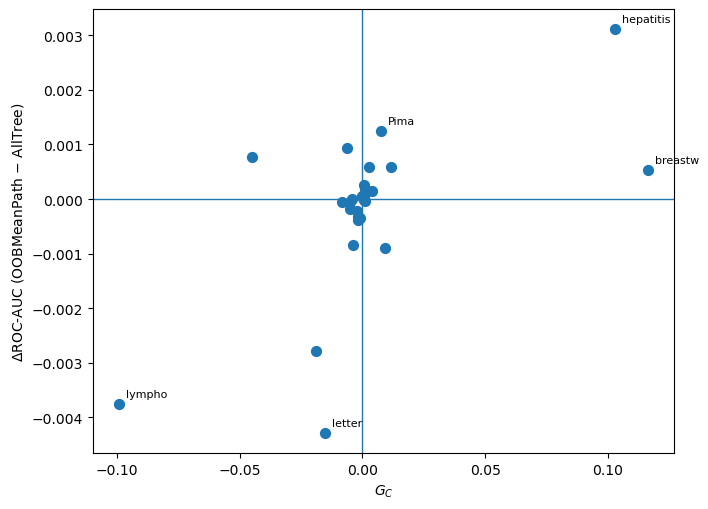

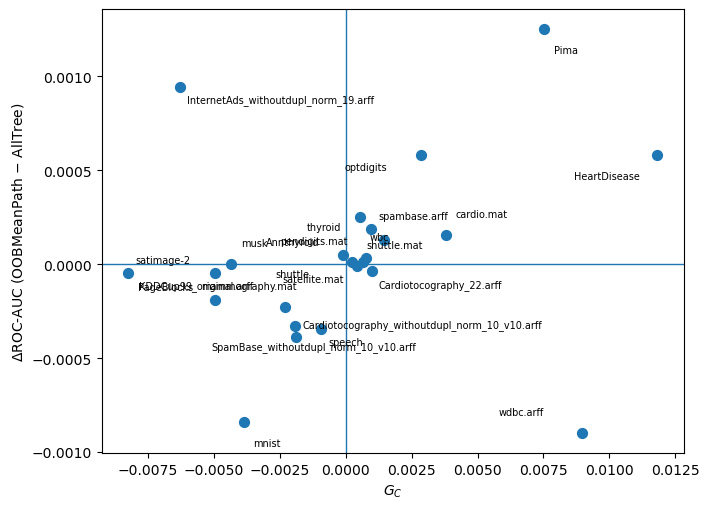

In [13]:
# ================================================================
# Refined Figure 1: class-differential correction vs controlled ROC
# ================================================================

from pathlib import Path

def _find_file_recursive(filename):
    candidates = [
        Path(filename),
        Path("OOBMeanPath_Unified_Ablation_outputs") / filename,
        Path.cwd() / filename,
        Path.cwd() / "OOBMeanPath_Unified_Ablation_outputs" / filename,
    ]
    for p in candidates:
        if p.exists():
            return p

    matches = list(Path.cwd().rglob(filename))
    if matches:
        return sorted(matches, key=lambda p: (len(p.parts), str(p)))[0]
    return None

if "main_summary" not in globals():
    _summary_file = _find_file_recursive(
        "Table_01_Main_SameForest_Ablation_T500.csv"
    )

    if _summary_file is not None:
        main_summary = pd.read_csv(_summary_file)
        print(f"Loaded main_summary from: {_summary_file}")
    else:
        _raw_file = _find_file_recursive("Ablation_T500_Seed_Level.csv")
        if _raw_file is None:
            _raw_file = _find_file_recursive("seed_level_results.csv")

        if _raw_file is None:
            raise FileNotFoundError(
                "Could not locate Table_01_Main_SameForest_Ablation_T500.csv, "
                "Ablation_T500_Seed_Level.csv, or seed_level_results.csv "
                "under the current working directory."
            )

        _raw = pd.read_csv(_raw_file)
        print(f"Reconstructing main_summary from: {_raw_file}")

        required_raw = {"dataset", "G_C", "OOB_minus_All_ROC"}
        missing_raw = required_raw.difference(_raw.columns)
        if missing_raw:
            raise KeyError(
                f"Raw file {_raw_file} is missing required columns: "
                f"{sorted(missing_raw)}"
            )

        main_summary = (
            _raw.groupby("dataset", sort=False)
            .agg(
                mean_G_C=("G_C", "mean"),
                mean_OOB_minus_All_ROC=("OOB_minus_All_ROC", "mean"),
            )
            .reset_index()
        )

_required_cols = {"dataset", "mean_G_C", "mean_OOB_minus_All_ROC"}
_missing_cols = _required_cols.difference(main_summary.columns)
if _missing_cols:
    raise KeyError(
        f"main_summary is missing required columns: {sorted(_missing_cols)}"
    )

if "OUTPUT_DIR" not in globals():
    if "_summary_file" in globals() and _summary_file is not None:
        OUTPUT_DIR = _summary_file.parent
    elif "_raw_file" in globals() and _raw_file is not None:
        OUTPUT_DIR = _raw_file.parent
    else:
        OUTPUT_DIR = Path.cwd()

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

short_name = {
    "Annthyroid_withoutdupl_07.arff": "Annthyroid",
    "HeartDisease_withoutdupl_44.arff": "HeartDisease",
    "PageBlocks_withoutdupl_norm_05_v10.arff": "PageBlocks",
    "Parkinson_withoutdupl_75.arff": "Parkinson",
    "Wilt_withoutdupl_norm_02_v10.arff": "Wilt",
    "breastw.mat": "breastw",
    "hepatitis.arff": "hepatitis",
    "letter.mat": "letter",
    "lympho.mat": "lympho",
    "mnist.mat": "mnist",
    "musk.mat": "musk",
    "optdigits.mat": "optdigits",
    "pima-indians-diabetes.arff": "Pima",
    "satimage-2.mat": "satimage-2",
    "seismic-bumps.arff": "seismic",
    "shuttle.arff": "shuttle",
    "shuttle.mat": "shuttle.mat",
    "speech.mat": "speech",
    "thyroid.mat": "thyroid",
    "wbc.mat": "wbc",
}

# Only label the most informative points in the full-range main figure.
# This avoids unreadable overlap near the origin.
main_labels = {
    "hepatitis.arff",
    "lympho.mat",
    "Parkinson_withoutdupl_75.arff",
    "letter.mat",
    "pima-indians-diabetes.arff",
    "breastw.mat",
}

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.scatter(
    main_summary["mean_G_C"],
    main_summary["mean_OOB_minus_All_ROC"],
    s=50,
)

ax.axhline(0.0, linewidth=1)
ax.axvline(0.0, linewidth=1)

for _, r in main_summary.iterrows():
    if r["dataset"] in main_labels:
        ax.annotate(
            short_name.get(r["dataset"], r["dataset"]),
            (r["mean_G_C"], r["mean_OOB_minus_All_ROC"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )

ax.set_xlabel(r"$G_C$")
ax.set_ylabel(r"$\Delta$ROC-AUC (OOBMeanPath $-$ AllTree)")

# Keep statistical details in the manuscript caption rather than
# using a large in-figure title.
fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "Fig_Final_GC_vs_Controlled_ROC.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    OUTPUT_DIR / "Fig_Final_GC_vs_Controlled_ROC.pdf",
    bbox_inches="tight",
)

plt.show()

# Separate zoomed diagnostic figure for the dense central region.
# This is useful for inspection or supplementary material, while
# the uncluttered full-range plot remains the main figure.
central = main_summary.loc[
    (main_summary["mean_G_C"].between(-0.012, 0.022))
    & (main_summary["mean_OOB_minus_All_ROC"].between(-0.00125, 0.00135))
].copy()

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.scatter(
    central["mean_G_C"],
    central["mean_OOB_minus_All_ROC"],
    s=50,
)

ax.axhline(0.0, linewidth=1)
ax.axvline(0.0, linewidth=1)

# Use compact alternating offsets to reduce label collisions.
offsets = [
    (5, 7), (5, -11), (-55, 7), (-55, -11),
    (7, 13), (7, -17), (-60, 13), (-60, -17),
]

for j, (_, r) in enumerate(central.sort_values("mean_G_C").iterrows()):
    dx, dy = offsets[j % len(offsets)]
    ax.annotate(
        short_name.get(r["dataset"], r["dataset"]),
        (r["mean_G_C"], r["mean_OOB_minus_All_ROC"]),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=7,
    )

ax.set_xlabel(r"$G_C$")
ax.set_ylabel(r"$\Delta$ROC-AUC (OOBMeanPath $-$ AllTree)")
fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "Fig_Final_GC_vs_Controlled_ROC_Zoom.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    OUTPUT_DIR / "Fig_Final_GC_vs_Controlled_ROC_Zoom.pdf",
    bbox_inches="tight",
)

plt.show()

## Part A summary: same-fitted-forest mechanism result

Interpret the primary result before looking for alternative statistics.

- A clearly positive primary relationship with stable leave-one-dataset-out behavior supports a cross-dataset mechanism claim.
- A weak or unstable relationship means the exact observation-level decomposition remains valid, but \(G_D\) should not be promoted as a general cross-dataset predictor.
- Do **not** search this notebook for a new gate, threshold, or replacement primary statistic.

In [14]:
loo_min = float(loo["spearman_rho_remaining"].min())
loo_median = float(loo["spearman_rho_remaining"].median())
sign_fraction = float(agg["sign_match_ROC"].mean())

print("=" * 80)
print("PART A: defined SAME-FOREST MECHANISM RESULT")
print("=" * 80)
print(f"N datasets                   : {len(agg)}")
print(f"T                            : {T}")
print(f"Seeds per dataset            : {len(SEEDS)}")
print(f"Primary Spearman rho         : {rho_primary:.6f}")
print(f"One-sided permutation p      : {p_primary:.6g}")
print(f"Sign agreement               : {int(agg['sign_match_ROC'].sum())}/{len(agg)} "
      f"({sign_fraction:.1%})")
print(f"LOO Spearman median          : {loo_median:.6f}")
print(f"LOO Spearman minimum         : {loo_min:.6f}")
print()
print("Secondary G_C vs ΔAP rho     :",
      f"{secondary.loc[secondary['analysis']=='G_C vs OOB-All AP','spearman_rho'].iloc[0]:.6f}")
print()
print("IMPORTANT:")
print("- Dataset is the independent unit for the primary inference.")
print(
    f"- Seed SDs measure forest-randomization stability, not "
    f"N={len(DATASETS) * len(SEEDS)} independent datasets."
)
print("- Do not redefine the primary endpoint after inspecting these outputs.")
print("=" * 80)

PART A: defined SAME-FOREST MECHANISM RESULT
N datasets                   : 30
T                            : 500
Seeds per dataset            : 20
Primary Spearman rho         : 0.528810
One-sided permutation p      : 0.00155999
Sign agreement               : 23/30 (76.7%)
LOO Spearman median          : 0.522660
LOO Spearman minimum         : 0.479803

Secondary G_C vs ΔAP rho     : 0.749944

IMPORTANT:
- Dataset is the independent unit for the primary inference.
- Seed SDs measure forest-randomization stability, not N=600 independent datasets.
- Do not redefine the primary endpoint after inspecting these outputs.


## Part A output files

The cells below continue with the unified tree-count/effective-OOB-tree ablation.

## Part B — Effective-OOB-tree and tree-count sensitivity on all datasets

This component evaluates the theoretically predicted Monte Carlo scaling law on
**every discovered benchmark dataset**, rather than on a restricted subset.

For every dataset and each of the 20 matched seeds, one 1000-tree forest is
fitted and the prefixes

\[
T\in\{100,250,500,1000\}
\]

are evaluated. Because all four checkpoints are nested prefixes of the same
1000-tree forest, differences across \(T\) are not confounded by independently
refitting forests.

For a fixed dataset, the theory gives

\[
\operatorname{MCSE}\!\left(\widehat{\mu}^{OOB}_i\right)
\propto [T(1-\psi/n)]^{-1/2}.
\]

Since \(q_{\mathrm{OOB}}=1-\psi/n\) is fixed with respect to \(T\) within a
dataset,

\[
\log(\operatorname{MCSE})=\alpha-\frac{1}{2}\log T,
\]

so the predicted log--log slope is \(-1/2\). This section evaluates that theoretical scaling prediction across the full discovered dataset collection.

In [15]:
# Run the nested-T experiment on EVERY discovered dataset.
# Resumable by dataset/seed. A separate filename is used so an older
# five-dataset sensitivity file cannot be mixed into this run.

RAW_T_ALL = OUTPUT_DIR / "t_sensitivity_seed_level_all_datasets.csv"

if RAW_T_ALL.exists():
    t_existing = pd.read_csv(RAW_T_ALL)
    required_resume_t = {"dataset", "seed", "T", "loader_version"}
    if required_resume_t.issubset(t_existing.columns):
        t_existing = t_existing.loc[
            t_existing["dataset"].isin(T_SENSITIVITY_DATASETS)
            & t_existing["seed"].isin(SEEDS)
            & t_existing["T"].isin(T_CHECKPOINTS)
            & (t_existing["loader_version"] == LOADER_VERSION)
        ].copy()
        t_existing = t_existing.drop_duplicates(
            ["dataset", "seed", "T"], keep="last"
        )
    else:
        warnings.warn(
            "Existing all-dataset T-sensitivity output has an incompatible "
            "schema; starting a clean run.",
            RuntimeWarning,
        )
        t_existing = pd.DataFrame()
else:
    t_existing = pd.DataFrame()

if t_existing.empty:
    done_t = set()
    t_rows = []
else:
    checkpoint_counts = t_existing.groupby(["dataset", "seed"])["T"].nunique()
    done_t = set(
        checkpoint_counts[checkpoint_counts == len(T_CHECKPOINTS)].index
    )
    keep_complete = [
        (str(d), int(s)) in done_t
        for d, s in zip(t_existing["dataset"], t_existing["seed"])
    ]
    t_existing = t_existing.loc[keep_complete].copy()
    t_rows = t_existing.to_dict("records")

total_jobs = len(T_SENSITIVITY_DATASETS) * len(SEEDS)
completed_jobs = len(done_t)

print("=" * 88)
print("ALL-DATASET TREE-COUNT / MCSE SCALING EXPERIMENT")
print("=" * 88)
print(f"Datasets       : {len(T_SENSITIVITY_DATASETS)}")
print(f"Seeds/dataset  : {len(SEEDS)}")
print(f"T checkpoints  : {T_CHECKPOINTS}")
print(f"Total jobs     : {total_jobs}")
print("=" * 88)

for di, name in enumerate(T_SENSITIVITY_DATASETS, 1):
    print("\n" + "=" * 88)
    print(f"[{di:02d}/{len(T_SENSITIVITY_DATASETS)}] {name}")

    X, y, feature_names, label_rule = load_dataset(DATASET_PATH_BY_NAME[name])
    validate_dataset(X, y, name)
    Xz = StandardScaler().fit_transform(X)

    for si, seed in enumerate(SEEDS, 1):
        key = (name, int(seed))
        if key in done_t:
            print(f"  seed {si:02d}/{len(SEEDS)} = {seed}: already complete")
            continue

        t0 = time.perf_counter()
        rows_here = fit_nested_checkpoints(Xz, y, seed, T_CHECKPOINTS)
        elapsed = time.perf_counter() - t0

        for r in rows_here:
            r["dataset"] = name
            r["loader_version"] = LOADER_VERSION
            r["label_rule"] = label_rule
            t_rows.append(r)

        # Atomic checkpoint after each completed dataset/seed job.
        current = pd.DataFrame(t_rows)
        tmp = RAW_T_ALL.with_suffix(".tmp.csv")
        current.to_csv(tmp, index=False, float_format="%.17g")
        tmp.replace(RAW_T_ALL)

        done_t.add(key)
        completed_jobs += 1
        last = rows_here[-1]
        print(
            f"  seed {si:02d}/{len(SEEDS)} = {seed}: "
            f"T1000 G_C={last['G_C']:+.6f}, "
            f"ΔROC={last['OOB_minus_All_ROC']:+.6f}, "
            f"median MCSE={last['median_oob_mcse']:.6f}, "
            f"time={elapsed:.1f}s [{completed_jobs}/{total_jobs}]"
        )

print("\nAll-dataset nested-T experiment complete.")
print("Saved:", RAW_T_ALL.resolve())

ALL-DATASET TREE-COUNT / MCSE SCALING EXPERIMENT
Datasets       : 30
Seeds/dataset  : 20
T checkpoints  : [100, 250, 500, 1000]
Total jobs     : 600

[01/30] Annthyroid_withoutdupl_07.arff
  seed 01/20 = 20270813: T1000 G_C=-0.000033, ΔROC=-0.000047, median MCSE=0.097272, time=3.4s [1/600]
  seed 02/20 = 20270814: T1000 G_C=+0.000478, ΔROC=+0.000078, median MCSE=0.098736, time=3.5s [2/600]
  seed 03/20 = 20270815: T1000 G_C=+0.001764, ΔROC=+0.000225, median MCSE=0.096611, time=3.7s [3/600]
  seed 04/20 = 20270816: T1000 G_C=+0.000492, ΔROC=+0.000103, median MCSE=0.097063, time=3.3s [4/600]
  seed 05/20 = 20270817: T1000 G_C=-0.000008, ΔROC=-0.000068, median MCSE=0.096822, time=3.4s [5/600]
  seed 06/20 = 20270818: T1000 G_C=-0.000774, ΔROC=+0.000079, median MCSE=0.096038, time=3.3s [6/600]
  seed 07/20 = 20270819: T1000 G_C=-0.000341, ΔROC=+0.000082, median MCSE=0.098104, time=3.4s [7/600]
  seed 08/20 = 20270820: T1000 G_C=-0.000655, ΔROC=-0.000108, median MCSE=0.095992, time=3.3s [8/

In [16]:
# Aggregate nested-T results to dataset × T.

t_raw_all = pd.read_csv(RAW_T_ALL)
t_raw_all = t_raw_all.loc[
    t_raw_all["dataset"].isin(T_SENSITIVITY_DATASETS)
    & t_raw_all["seed"].isin(SEEDS)
    & t_raw_all["T"].isin(T_CHECKPOINTS)
    & (t_raw_all["loader_version"] == LOADER_VERSION)
].drop_duplicates(["dataset", "seed", "T"], keep="last")

expected_rows = (
    len(T_SENSITIVITY_DATASETS)
    * len(SEEDS)
    * len(T_CHECKPOINTS)
)

if len(t_raw_all) != expected_rows:
    counts = (
        t_raw_all.groupby(["dataset", "seed"])["T"]
        .nunique()
        .reset_index(name="n_checkpoints")
    )
    incomplete = counts.loc[counts["n_checkpoints"] != len(T_CHECKPOINTS)]
    raise RuntimeError(
        f"Incomplete all-dataset nested-T output: expected {expected_rows} rows, "
        f"got {len(t_raw_all)}. Incomplete dataset/seed jobs: "
        f"{len(incomplete)}."
    )

dataset_T_all = (
    t_raw_all.groupby(["dataset", "T"], sort=False)
    .agg(
        n=("n", "first"),
        d=("d", "first"),
        prevalence=("prevalence", "first"),
        psi=("psi", "first"),
        q_oob=("q_oob", "first"),
        expected_oob_trees=("expected_oob_trees", "first"),
        mean_G_C=("G_C", "mean"),
        sd_G_C=("G_C", "std"),
        mean_G_D_full=("G_D_full", "mean"),
        sd_G_D_full=("G_D_full", "std"),
        mean_median_oob_mcse=("median_oob_mcse", "mean"),
        sd_median_oob_mcse=("median_oob_mcse", "std"),
        mean_mean_oob_mcse=("mean_oob_mcse", "mean"),
        AllTree_ROC=("AllTree_ROC", "mean"),
        OOBMeanPath_ROC=("OOBMeanPath_ROC", "mean"),
        mean_OOB_minus_All_ROC=("OOB_minus_All_ROC", "mean"),
        sd_OOB_minus_All_ROC=("OOB_minus_All_ROC", "std"),
        AllTree_AP=("AllTree_AP", "mean"),
        OOBMeanPath_AP=("OOBMeanPath_AP", "mean"),
        mean_OOB_minus_All_AP=("OOB_minus_All_AP", "mean"),
        sd_OOB_minus_All_AP=("OOB_minus_All_AP", "std"),
    )
    .reset_index()
)

dataset_T_all["MCSE_sqrt_Tq"] = (
    dataset_T_all["mean_median_oob_mcse"]
    * np.sqrt(dataset_T_all["T"] * dataset_T_all["q_oob"])
)

DATASET_T_ALL_FILE = OUTPUT_DIR / "t_sensitivity_dataset_T_all_datasets.csv"
dataset_T_all.to_csv(
    DATASET_T_ALL_FILE,
    index=False,
    float_format="%.17g",
)

display(dataset_T_all)
print("Saved:", DATASET_T_ALL_FILE.resolve())

,dataset,T,n,d,prevalence,psi,q_oob,expected_oob_trees,mean_G_C,sd_G_C,...,mean_mean_oob_mcse,AllTree_ROC,OOBMeanPath_ROC,mean_OOB_minus_All_ROC,sd_OOB_minus_All_ROC,AllTree_AP,OOBMeanPath_AP,mean_OOB_minus_All_AP,sd_OOB_minus_All_AP,MCSE_sqrt_Tq
0,Annthyroid_withoutdupl_07.arff,100,7129,22,0.074905,256,0.964090,96.409034,-0.001237,0.003574,...,0.320361,0.619871,0.619608,-0.000263,0.000497,0.116738,0.116761,0.000023,0.000468,3.026233
1,Annthyroid_withoutdupl_07.arff,250,7129,22,0.074905,256,0.964090,241.022584,-0.000530,0.002341,...,0.203018,0.620891,0.620854,-0.000037,0.000367,0.116504,0.116499,-0.000005,0.000235,3.014998
2,Annthyroid_withoutdupl_07.arff,500,7129,22,0.074905,256,0.964090,482.045168,-0.000115,0.001577,...,0.143572,0.619086,0.619135,0.000049,0.000255,0.115456,0.115518,0.000062,0.000142,3.011947
3,Annthyroid_withoutdupl_07.arff,1000,7129,22,0.074905,256,0.964090,964.090335,-0.000151,0.001133,...,0.101619,0.619154,0.619180,0.000026,0.000167,0.115271,0.115370,0.000099,0.000148,3.010552
4,arrhythmia.arff,100,452,326,0.457965,256,0.433628,43.362832,-0.028893,0.035609,...,0.489456,0.744692,0.741123,-0.003569,0.009612,0.745668,0.740359,-0.005309,0.008400,3.087062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,wbc.mat,1000,378,30,0.055556,256,0.322751,322.751323,0.006571,0.040045,...,0.172961,0.941196,0.942097,0.000900,0.002928,0.604443,0.613863,0.009420,0.009942,3.092239
116,wdbc.arff,100,569,30,0.372583,256,0.550088,55.008787,0.000137,0.023966,...,0.420344,0.792096,0.785009,-0.007087,0.003312,0.659686,0.655516,-0.004170,0.004468,3.109080
117,wdbc.arff,250,569,30,0.372583,256,0.550088,137.521968,0.008285,0.014117,...,0.267254,0.794595,0.792230,-0.002365,0.002461,0.660579,0.661177,0.000598,0.003843,3.135370
118,wdbc.arff,500,569,30,0.372583,256,0.550088,275.043937,0.008975,0.011830,...,0.188572,0.798148,0.797248,-0.000900,0.002013,0.663846,0.666184,0.002338,0.002592,3.134294


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Ablation Study 3\OOBMeanPath_Unified_Ablation_outputs\t_sensitivity_dataset_T_all_datasets.csv


In [17]:
# Verify the theoretical T^{-1/2} MCSE scaling law on every dataset.

from scipy.stats import ttest_1samp

scaling_rows = []

for dataset, g in dataset_T_all.groupby("dataset", sort=False):
    g = g.sort_values("T")

    if list(g["T"].astype(int)) != list(T_CHECKPOINTS):
        raise RuntimeError(
            f"{dataset}: expected T checkpoints {T_CHECKPOINTS}, "
            f"got {list(g['T'].astype(int))}"
        )

    Tvals = g["T"].to_numpy(dtype=float)
    mcse = g["mean_median_oob_mcse"].to_numpy(dtype=float)
    sd_gc = g["sd_G_C"].to_numpy(dtype=float)
    scaled = g["MCSE_sqrt_Tq"].to_numpy(dtype=float)

    if np.any(~np.isfinite(mcse)) or np.any(mcse <= 0):
        raise RuntimeError(f"{dataset}: nonpositive/nonfinite MCSE encountered.")

    slope = float(np.polyfit(np.log(Tvals), np.log(mcse), 1)[0])
    ratio = float(mcse[-1] / mcse[0])
    scaled_cv = float(np.std(scaled, ddof=1) / np.mean(scaled))

    if np.all(np.isfinite(sd_gc)) and np.all(sd_gc > 0):
        sd_gc_slope = float(
            np.polyfit(np.log(Tvals), np.log(sd_gc), 1)[0]
        )
    else:
        sd_gc_slope = np.nan

    scaling_rows.append({
        "dataset": dataset,
        "n": int(g["n"].iloc[0]),
        "d": int(g["d"].iloc[0]),
        "prevalence": float(g["prevalence"].iloc[0]),
        "psi": int(g["psi"].iloc[0]),
        "q_oob": float(g["q_oob"].iloc[0]),
        "MCSE_loglog_slope": slope,
        "theoretical_MCSE_slope": -0.5,
        "slope_minus_theory": slope + 0.5,
        "abs_slope_error": abs(slope + 0.5),
        "MCSE_ratio_T1000_over_T100": ratio,
        "theoretical_ratio_sqrt_0p1": math.sqrt(0.1),
        "ratio_minus_theory": ratio - math.sqrt(0.1),
        "CV_of_MCSE_times_sqrt_Tq": scaled_cv,
        "seed_SD_GC_loglog_slope": sd_gc_slope,
    })

scaling_all = pd.DataFrame(scaling_rows)

# Dataset is the independent unit for the cross-dataset scaling summary.
slopes = scaling_all["MCSE_loglog_slope"].to_numpy(dtype=float)
ratios = scaling_all["MCSE_ratio_T1000_over_T100"].to_numpy(dtype=float)
abs_err = scaling_all["abs_slope_error"].to_numpy(dtype=float)

n_datasets_scaling = len(slopes)
mean_slope = float(np.mean(slopes))
median_slope = float(np.median(slopes))
sd_slope = float(np.std(slopes, ddof=1))
se_mean_slope = float(sd_slope / np.sqrt(n_datasets_scaling))

# 95% CI for the mean dataset slope.
from scipy.stats import t as student_t
tcrit = float(student_t.ppf(0.975, df=n_datasets_scaling - 1))
ci_low = mean_slope - tcrit * se_mean_slope
ci_high = mean_slope + tcrit * se_mean_slope

# This test is reported only as a diagnostic of departure from the theoretical
# value; failure to reject is NOT treated as proof of equality.
tt = ttest_1samp(slopes, popmean=-0.5)

overall_scaling = pd.DataFrame([{
    "n_datasets": n_datasets_scaling,
    "mean_MCSE_loglog_slope": mean_slope,
    "median_MCSE_loglog_slope": median_slope,
    "sd_dataset_slopes": sd_slope,
    "theoretical_slope": -0.5,
    "mean_slope_minus_theory": mean_slope + 0.5,
    "mean_abs_slope_error": float(np.mean(abs_err)),
    "max_abs_slope_error": float(np.max(abs_err)),
    "fraction_within_0p02_of_minus_0p5": float(np.mean(abs_err <= 0.02)),
    "fraction_within_0p05_of_minus_0p5": float(np.mean(abs_err <= 0.05)),
    "fraction_within_0p10_of_minus_0p5": float(np.mean(abs_err <= 0.10)),
    "mean_slope_95CI_low": float(ci_low),
    "mean_slope_95CI_high": float(ci_high),
    "t_test_vs_minus_0p5_statistic": float(tt.statistic),
    "t_test_vs_minus_0p5_p_two_sided": float(tt.pvalue),
    "mean_MCSE_ratio_T1000_over_T100": float(np.mean(ratios)),
    "median_MCSE_ratio_T1000_over_T100": float(np.median(ratios)),
    "theoretical_ratio_sqrt_0p1": math.sqrt(0.1),
    "mean_ratio_minus_theory": float(np.mean(ratios) - math.sqrt(0.1)),
    "mean_CV_of_MCSE_times_sqrt_Tq": float(
        scaling_all["CV_of_MCSE_times_sqrt_Tq"].mean()
    ),
    "median_CV_of_MCSE_times_sqrt_Tq": float(
        scaling_all["CV_of_MCSE_times_sqrt_Tq"].median()
    ),
}])

SCALING_ALL_FILE = OUTPUT_DIR / "mcse_scaling_all_datasets.csv"
SCALING_SUMMARY_FILE = OUTPUT_DIR / "mcse_scaling_overall_summary.csv"

scaling_all.to_csv(
    SCALING_ALL_FILE,
    index=False,
    float_format="%.17g",
)
overall_scaling.to_csv(
    SCALING_SUMMARY_FILE,
    index=False,
    float_format="%.17g",
)

display(scaling_all.sort_values("MCSE_loglog_slope"))
display(overall_scaling)

print("=" * 88)
print("ALL-DATASET TEST OF THE THEORETICAL T^{-1/2} MCSE LAW")
print("=" * 88)
print(f"N datasets                        : {n_datasets_scaling}")
print(f"Theoretical log-log slope         : -0.500000")
print(f"Mean empirical slope              : {mean_slope:.6f}")
print(f"Median empirical slope            : {median_slope:.6f}")
print(f"95% CI for mean dataset slope     : [{ci_low:.6f}, {ci_high:.6f}]")
print(f"Mean absolute slope error         : {np.mean(abs_err):.6f}")
print(f"Maximum absolute slope error      : {np.max(abs_err):.6f}")
print(f"Fraction within ±0.02             : {np.mean(abs_err <= 0.02):.1%}")
print(f"Fraction within ±0.05             : {np.mean(abs_err <= 0.05):.1%}")
print(f"Fraction within ±0.10             : {np.mean(abs_err <= 0.10):.1%}")
print()
print(f"Theoretical MCSE ratio 1000/100   : {math.sqrt(0.1):.6f}")
print(f"Mean empirical ratio 1000/100     : {np.mean(ratios):.6f}")
print(f"Median empirical ratio 1000/100   : {np.median(ratios):.6f}")
print()
print(
    "Mean CV of MCSE*sqrt(T*q_OOB)    : "
    f"{scaling_all['CV_of_MCSE_times_sqrt_Tq'].mean():.6f}"
)
print("=" * 88)

print("\nInterpretation rule:")
print(
    "The theoretical claim is supported when the dataset-level slopes cluster "
    "near -0.5, the 1000/100 MCSE ratios cluster near sqrt(0.1), and "
    "MCSE*sqrt(T*q_OOB) is approximately constant within datasets."
)
print(
    "Do not interpret a nonsignificant t-test versus -0.5 as proof of exact "
    "equality; the closeness diagnostics above are the primary verification."
)

,dataset,n,d,prevalence,psi,q_oob,MCSE_loglog_slope,theoretical_MCSE_slope,slope_minus_theory,abs_slope_error,MCSE_ratio_T1000_over_T100,theoretical_ratio_sqrt_0p1,ratio_minus_theory,CV_of_MCSE_times_sqrt_Tq,seed_SD_GC_loglog_slope
28,wbc.mat,378,30,0.055556,256,0.322751,-0.503778,-0.5,-0.003778,0.003778,0.313436,0.316228,-0.002792,0.004101,-0.528094
0,Annthyroid_withoutdupl_07.arff,7129,22,0.074905,256,0.964090,-0.502243,-0.5,-0.002243,0.002243,0.314589,0.316228,-0.001639,0.002359,-0.504418
21,shuttle.arff,58000,9,0.214034,256,0.995586,-0.502167,-0.5,-0.002167,0.002167,0.314670,0.316228,-0.001557,0.002576,-0.530980
20,satimage-2.mat,5803,36,0.012235,256,0.955885,-0.501155,-0.5,-0.001155,0.001155,0.315414,0.316228,-0.000814,0.001236,-0.534990
3,cardio.mat,1831,21,0.096122,256,0.860186,-0.500986,-0.5,-0.000986,0.000986,0.315615,0.316228,-0.000612,0.001191,-0.392755
4,Cardiotocography_22.arff,2126,22,0.221543,256,0.879586,-0.500746,-0.5,-0.000746,0.000746,0.315614,0.316228,-0.000614,0.001258,-0.621742
19,satellite.mat,6435,36,0.316395,256,0.960218,-0.499493,-0.5,0.000507,0.000507,0.316680,0.316228,0.000452,0.001065,-0.439285
23,spambase.arff,4601,57,0.394045,256,0.944360,-0.499322,-0.5,0.000678,0.000678,0.316754,0.316228,0.000527,0.000949,-0.450578
17,pendigits.mat,6870,16,0.022707,256,0.962737,-0.499296,-0.5,0.000704,0.000704,0.317016,0.316228,0.000788,0.002099,-0.558235
18,pima-indians-diabetes.arff,768,8,0.348958,256,0.666667,-0.499210,-0.5,0.000790,0.000790,0.317046,0.316228,0.000818,0.001314,-0.469840


,n_datasets,mean_MCSE_loglog_slope,median_MCSE_loglog_slope,sd_dataset_slopes,theoretical_slope,mean_slope_minus_theory,mean_abs_slope_error,max_abs_slope_error,fraction_within_0p02_of_minus_0p5,fraction_within_0p05_of_minus_0p5,...,mean_slope_95CI_low,mean_slope_95CI_high,t_test_vs_minus_0p5_statistic,t_test_vs_minus_0p5_p_two_sided,mean_MCSE_ratio_T1000_over_T100,median_MCSE_ratio_T1000_over_T100,theoretical_ratio_sqrt_0p1,mean_ratio_minus_theory,mean_CV_of_MCSE_times_sqrt_Tq,median_CV_of_MCSE_times_sqrt_Tq
0,30,-0.497945,-0.498334,0.003281,-0.5,0.002055,0.002793,0.012634,1.0,1.0,...,-0.499171,-0.49672,3.429542,0.001834,0.317756,0.31737,0.316228,0.001528,0.003218,0.002467


ALL-DATASET TEST OF THE THEORETICAL T^{-1/2} MCSE LAW
N datasets                        : 30
Theoretical log-log slope         : -0.500000
Mean empirical slope              : -0.497945
Median empirical slope            : -0.498334
95% CI for mean dataset slope     : [-0.499171, -0.496720]
Mean absolute slope error         : 0.002793
Maximum absolute slope error      : 0.012634
Fraction within ±0.02             : 100.0%
Fraction within ±0.05             : 100.0%
Fraction within ±0.10             : 100.0%

Theoretical MCSE ratio 1000/100   : 0.316228
Mean empirical ratio 1000/100     : 0.317756
Median empirical ratio 1000/100   : 0.317370

Mean CV of MCSE*sqrt(T*q_OOB)    : 0.003218

Interpretation rule:
The theoretical claim is supported when the dataset-level slopes cluster near -0.5, the 1000/100 MCSE ratios cluster near sqrt(0.1), and MCSE*sqrt(T*q_OOB) is approximately constant within datasets.
Do not interpret a nonsignificant t-test versus -0.5 as proof of exact equality; the clos

In [18]:
# T=500 versus T=1000 convergence and G_C/effect pattern across all datasets.

def _vec_all(Tnow, col):
    return (
        dataset_T_all.loc[
            dataset_T_all["T"] == Tnow,
            ["dataset", col],
        ]
        .set_index("dataset")
        .reindex(T_SENSITIVITY_DATASETS)[col]
        .to_numpy(dtype=float)
    )

conv_rows = []

for metric, col in [
    ("ROC", "mean_OOB_minus_All_ROC"),
    ("AP", "mean_OOB_minus_All_AP"),
]:
    v500 = _vec_all(500, col)
    v1000 = _vec_all(1000, col)

    conv_rows.append({
        "comparison": f"T500 vs T1000 controlled {metric}",
        "spearman_rho": float(spearmanr(v500, v1000).statistic),
        "sign_agreement": float(np.mean(np.sign(v500) == np.sign(v1000))),
        "mean_absolute_difference": float(np.mean(np.abs(v500 - v1000))),
    })

for Tnow in T_CHECKPOINTS:
    gc = _vec_all(Tnow, "mean_G_C")
    dr = _vec_all(Tnow, "mean_OOB_minus_All_ROC")
    da = _vec_all(Tnow, "mean_OOB_minus_All_AP")

    conv_rows.append({
        "comparison": f"G_C vs controlled ROC at T={Tnow}",
        "spearman_rho": float(spearmanr(gc, dr).statistic),
        "sign_agreement": float(np.mean(np.sign(gc) == np.sign(dr))),
        "mean_absolute_difference": np.nan,
    })
    conv_rows.append({
        "comparison": f"G_C vs controlled AP at T={Tnow}",
        "spearman_rho": float(spearmanr(gc, da).statistic),
        "sign_agreement": float(np.mean(np.sign(gc) == np.sign(da))),
        "mean_absolute_difference": np.nan,
    })

convergence_all = pd.DataFrame(conv_rows)

CONVERGENCE_ALL_FILE = (
    OUTPUT_DIR / "t_convergence_and_mechanism_all_datasets.csv"
)
convergence_all.to_csv(
    CONVERGENCE_ALL_FILE,
    index=False,
    float_format="%.17g",
)

display(convergence_all)
print("Saved:", CONVERGENCE_ALL_FILE.resolve())

,comparison,spearman_rho,sign_agreement,mean_absolute_difference
0,T500 vs T1000 controlled ROC,0.919911,0.900000,0.000204
1,T500 vs T1000 controlled AP,0.978643,1.000000,0.000640
2,G_C vs controlled ROC at T=100,0.354394,0.666667,NaN
3,G_C vs controlled AP at T=100,0.737041,0.800000,NaN
4,G_C vs controlled ROC at T=250,0.520356,0.766667,NaN
5,G_C vs controlled AP at T=250,0.693437,0.833333,NaN
6,G_C vs controlled ROC at T=500,0.528810,0.766667,NaN
7,G_C vs controlled AP at T=500,0.749944,0.800000,NaN
8,G_C vs controlled ROC at T=1000,0.623137,0.800000,NaN
9,G_C vs controlled AP at T=1000,0.766407,0.800000,NaN


Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Ablation Study 3\OOBMeanPath_Unified_Ablation_outputs\t_convergence_and_mechanism_all_datasets.csv


In [19]:
# Reproducibility cross-check on ALL datasets:
# standalone T=500 from Part A versus the T=500 prefix of the independently
# fitted T=1000 forest, using the same seeds/settings.

main_all = (
    agg.loc[
        agg["dataset"].isin(T_SENSITIVITY_DATASETS),
        [
            "dataset",
            "mean_G_C",
            "mean_OOB_minus_All_ROC",
            "mean_OOB_minus_All_AP",
        ],
    ]
    .set_index("dataset")
    .reindex(T_SENSITIVITY_DATASETS)
)

nested_all = (
    dataset_T_all.loc[
        dataset_T_all["T"] == 500,
        [
            "dataset",
            "mean_G_C",
            "mean_OOB_minus_All_ROC",
            "mean_OOB_minus_All_AP",
        ],
    ]
    .set_index("dataset")
    .reindex(T_SENSITIVITY_DATASETS)
)

cross_rows = []
for dset in T_SENSITIVITY_DATASETS:
    cross_rows.append({
        "dataset": dset,
        "abs_diff_G_C": abs(
            float(main_all.loc[dset, "mean_G_C"])
            - float(nested_all.loc[dset, "mean_G_C"])
        ),
        "abs_diff_delta_ROC": abs(
            float(main_all.loc[dset, "mean_OOB_minus_All_ROC"])
            - float(nested_all.loc[dset, "mean_OOB_minus_All_ROC"])
        ),
        "abs_diff_delta_AP": abs(
            float(main_all.loc[dset, "mean_OOB_minus_All_AP"])
            - float(nested_all.loc[dset, "mean_OOB_minus_All_AP"])
        ),
    })

crosscheck_all = pd.DataFrame(cross_rows)
CROSSCHECK_ALL_FILE = (
    OUTPUT_DIR / "T500_nested_reproducibility_all_datasets.csv"
)

crosscheck_all.to_csv(
    CROSSCHECK_ALL_FILE,
    index=False,
    float_format="%.17g",
)

display(crosscheck_all)
print(
    "Maximum discrepancy:",
    crosscheck_all.iloc[:, 1:].to_numpy(dtype=float).max(),
)
print("Saved:", CROSSCHECK_ALL_FILE.resolve())

,dataset,abs_diff_G_C,abs_diff_delta_ROC,abs_diff_delta_AP
0,Annthyroid_withoutdupl_07.arff,0.0,0.0,0.0
1,arrhythmia.arff,0.0,0.0,0.0
2,breastw.mat,0.0,0.0,0.0
3,cardio.mat,0.0,0.0,0.0
4,Cardiotocography_22.arff,0.0,0.0,0.0
5,Cardiotocography_withoutdupl_norm_10_v10.arff,0.0,0.0,0.0
6,HeartDisease_withoutdupl_44.arff,0.0,0.0,0.0
7,hepatitis.arff,0.0,0.0,0.0
8,InternetAds_withoutdupl_norm_19.arff,0.0,0.0,0.0
9,KDDCup99_original.arff,0.0,0.0,0.0


Maximum discrepancy: 0.0
Saved: C:\Users\jzhou\Desktop\Academics\Research\Outlier Detection\OOBMeanPath\Refined and subject to sumit version\Ablation Study 3\OOBMeanPath_Unified_Ablation_outputs\T500_nested_reproducibility_all_datasets.csv


## All-dataset MCSE scaling figures

The first figure uses the geometric mean of the dataset-level MCSE at each
tree count, with the \(T^{-1/2}\) reference curve anchored at \(T=100\).
Because every dataset is included in the geometric mean at every checkpoint,
the figure does not privilege any individual dataset.

The second figure shows the distribution of the individual dataset log--log
slopes around the theoretical value \(-0.5\). The exact dataset-level values
are retained in `mcse_scaling_all_datasets.csv`.

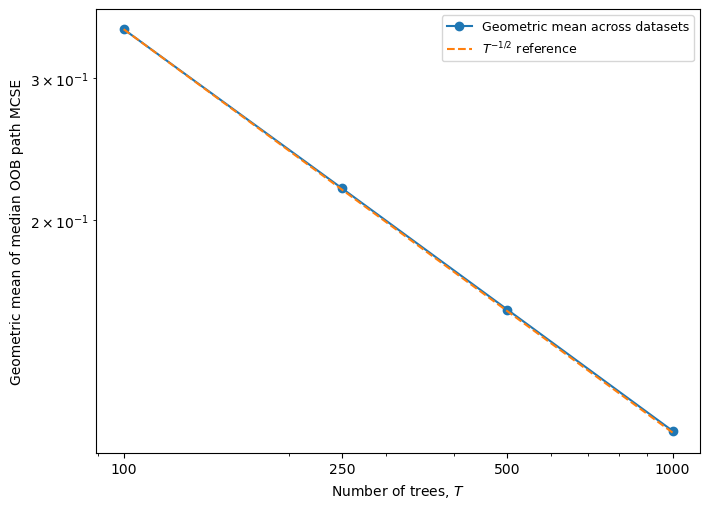

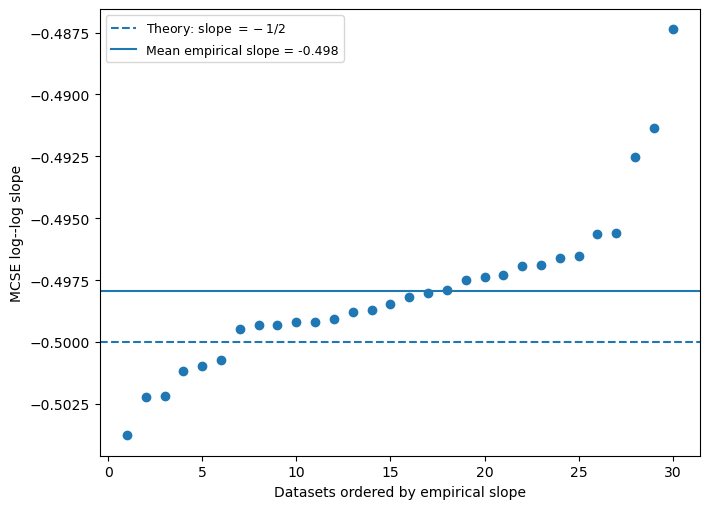

In [20]:
# ================================================================
# Figure A: geometric-mean MCSE across ALL datasets vs T^{-1/2}
# ================================================================

plot_summary = (
    dataset_T_all.groupby("T", sort=True)
    .agg(
        geometric_mean_mcse=(
            "mean_median_oob_mcse",
            lambda x: float(np.exp(np.mean(np.log(np.asarray(x, dtype=float))))),
        ),
        median_mcse=("mean_median_oob_mcse", "median"),
    )
    .reset_index()
)

t_ref = plot_summary["T"].to_numpy(dtype=float)
gm_mcse = plot_summary["geometric_mean_mcse"].to_numpy(dtype=float)

anchor = float(gm_mcse[0])
y_ref = anchor * np.sqrt(t_ref[0] / t_ref)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(
    t_ref,
    gm_mcse,
    marker="o",
    label="Geometric mean across datasets",
)
ax.plot(
    t_ref,
    y_ref,
    linestyle="--",
    label=r"$T^{-1/2}$ reference",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(T_CHECKPOINTS)
ax.set_xticklabels([str(t) for t in T_CHECKPOINTS])
ax.set_xlabel("Number of trees, $T$")
ax.set_ylabel("Geometric mean of median OOB path MCSE")
ax.legend(fontsize=9)
fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "Fig_MCSE_Scaling_AllDatasets.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    OUTPUT_DIR / "Fig_MCSE_Scaling_AllDatasets.pdf",
    bbox_inches="tight",
)
plt.show()


# ================================================================
# Figure B: distribution of dataset-level log-log slopes
# ================================================================

slopes_sorted = np.sort(
    scaling_all["MCSE_loglog_slope"].to_numpy(dtype=float)
)
xpos = np.arange(1, len(slopes_sorted) + 1)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.plot(xpos, slopes_sorted, marker="o", linestyle="none")
ax.axhline(-0.5, linestyle="--", label=r"Theory: slope $=-1/2$")
ax.axhline(
    float(np.mean(slopes_sorted)),
    linestyle="-",
    label=f"Mean empirical slope = {np.mean(slopes_sorted):.3f}",
)

ax.set_xlabel("Datasets ordered by empirical slope")
ax.set_ylabel("MCSE log--log slope")
ax.legend(fontsize=9)
fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "Fig_MCSE_Slope_Distribution.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    OUTPUT_DIR / "Fig_MCSE_Slope_Distribution.pdf",
    bbox_inches="tight",
)
plt.show()

# Final ablation output manifest

The unified notebook produces the same-fitted-forest mechanism outputs from
Part A and the all-dataset tree-count verification outputs from Part B.

### Main same-fitted-forest ablation
- `seed_level_results.csv`
- `dataset_summary.csv`
- `primary_mechanism_test.csv`
- `secondary_diagnostics.csv`
- `leave_one_dataset_out.csv`
- `partial_rank_robustness.csv`
- `controlled_effect_summary.csv`
- `Fig_Final_GC_vs_Controlled_ROC.png/.pdf`

### All-dataset effective-tree-count / MCSE scaling
- `t_sensitivity_seed_level_all_datasets.csv`
- `t_sensitivity_dataset_T_all_datasets.csv`
- `mcse_scaling_all_datasets.csv`
- `mcse_scaling_overall_summary.csv`
- `t_convergence_and_mechanism_all_datasets.csv`
- `T500_nested_reproducibility_all_datasets.csv`
- `Fig_MCSE_Scaling_AllDatasets.png/.pdf`
- `Fig_MCSE_Slope_Distribution.png/.pdf`

Keep both seed-level CSV files in the reproducibility archive.